---
## Summary



| Metric | **Colab A100 (15,090)** |
|--------|---------------------|
| **Fused Val AUROC** | **0.8798** |
| CEV Val AUROC |  0.8723 |
| IAV Val AUROC | **0.8751** |
| Mean Accuracy |  **78.8%** |
| **HaluEval Mean AUROC** |  **0.9062** |
| Val Split Size |  **3,058** |
| Runtime |  **94 min** |

### Cross-Model Comparison:

| | Mistral-7B (Colab) | **Qwen3-8B (Colab)** |
|--|-------------------|---------------------|
| Fused Val AUROC | 0.8515 | **0.8798** |
| HaluEval AUROC | 0.13 | **0.906** |
| Mean Accuracy | 77.4% | **78.8%** |
| Demo Quality | 7/9 correct | **7/9 correct** |

### Key Finding:
Qwen3-8B internal states carry **strong hallucination signal that generalizes across domains**.
HaluEval AUROC 0.906 (vs Mistral 0.13) shows Qwen MLP activations encode factual grounding
in a way that transfers beyond the training distribution.


---
## Probe layer configuration - single MID layer (N/2)

**This pipeline now trains a single-layer probe at half depth.**
`Config.probe_concat_n_layers = 1`, so the CEV/IAV features are read from the **mid
layer `N/2` only** - for Qwen3-8B (36 layers) that is **layer 18**. (The code
maps `probe_concat_n_layers <= 1` to `target_layers = [N // 2]`.)

**Why mid, not the old 3-layer (early/mid/late) concat?** The cross-model layer-wise
probe ablation showed the **single mid layer is the best system-agnostic choice**:

- it has the **best or tied-best AUROC** in every model tested and **wins
  Llama-3-8B-Instruct outright** on all three metrics (AUROC / Accuracy / F1) with the
  **lowest seed-to-seed variance**;
- it uses **~1/3 of the parameters** of the 3-layer concat (~4.26M vs
  ~12.65M probe params);
- the **3-layer triple never won a single metric** in any model, so its ~3x parameter
  cost is **not justified**.

See **`compare-models__Layer_wise_probe_ablation.ipynb`** for the full single / double /
triple comparison across Qwen3-8B, Mistral-7B and Llama-3-8B-Instruct, plus the
average-rank table behind this recommendation.

> **Recalibrate `hallucination_threshold` after this change.** Moving from the 3-layer
> concat to the single mid layer changes the probe input width and the fused-score
> distribution, so the previously tuned decision threshold(s) must be **re-fit on the
> validation split** before deployment.

---
## Cell 1: Environment Setup

In [1]:
# Install required dependencies
!pip install -q transformers>=4.40.0 accelerate>=0.29.0 bitsandbytes>=0.46.1
!pip install -q peft einops sentencepiece safetensors
!pip install -q datasets gdown sentence-transformers
!pip install -q scikit-learn tqdm matplotlib seaborn

# faiss-gpu was removed from PyPI after v1.7.2.
# Try faiss-gpu first (works on some Colab GPU images); fall back to faiss-cpu.
!pip install -q faiss-gpu 2>/dev/null || pip install -q faiss-cpu

import os
import importlib
import warnings
warnings.filterwarnings('ignore')

# ── Google Drive mount ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── HuggingFace authentication via Colab Secrets ────────────────────────────
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
from huggingface_hub import login
login(token=hf_token)

# Set cache directories — use /tmp/ (large system disk) instead of
# /content/ (only ~100 GiB, needed for outputs/checkpoints).
os.environ["HF_HOME"] = "/tmp/hf_cache"
os.environ["TRANSFORMERS_CACHE"] = "/tmp/hf_cache"
os.environ["HF_DATASETS_CACHE"] = "/tmp/datasets_cache"
os.environ["HF_TOKEN"] = hf_token

os.makedirs("/tmp/hf_cache", exist_ok=True)
os.makedirs("/tmp/datasets_cache", exist_ok=True)

# ── Google Drive output directories ────────────────────────────────────────
os.makedirs("/content/drive/MyDrive/qwen_rag_hallucination/outputs", exist_ok=True)
os.makedirs("/content/drive/MyDrive/qwen_rag_hallucination/checkpoints", exist_ok=True)

# Post-install sanity check — surface failures before Cell 2 crashes on import
print("Checking key packages:")
for _pkg in ["faiss", "sentence_transformers", "datasets", "transformers"]:
    if importlib.util.find_spec(_pkg) is None:
        print(f"  WARNING: '{_pkg}' not importable — re-run this cell or install manually")
    else:
        print(f"  OK: {_pkg}")

print("\nEnvironment setup complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 119.2 MB/s eta 0:00:00
Mounted at /content/drive
Checking key packages:
  OK: faiss
  OK: sentence_transformers
  OK: datasets
  OK: transformers

Environment setup complete!


---
## Cell 2: Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import json
from tqdm.auto import tqdm
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass
from collections import defaultdict
import pickle
import time
import gc
import random
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    GenerationConfig
)
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
try:
    import faiss
except ImportError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "faiss-cpu"],
        capture_output=True,
    )
    import faiss
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, classification_report,
    confusion_matrix, roc_curve,
)
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

# Check GPU availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"    Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.2f} GB")

PyTorch version: 2.11.0+cu128
CUDA available: True
Number of GPUs: 1
  GPU 0: NVIDIA A100-SXM4-40GB
    Memory: 42.41 GB


---
## Cell 3: Configuration

In [3]:
@dataclass
class Config:
    """Configuration for the hallucination detection pipeline."""

    # Model selection
    model_name: str = "Qwen/Qwen3-8B"

    # Quantization settings
    use_8bit: bool = False  # FP16 for A100 — better hidden state quality
    use_4bit: bool = False  # Not needed on A100

    # Hidden state extraction (CEV = block output; IAV = MLP input to down_proj)
    target_layers: Optional[List[int]] = None  # None = auto mid-band (set after model load)
    hidden_size: int = 4096  # Overwritten from model.config after load
    intermediate_size: int = 12288  # Overwritten from model.config after load

    # RAG settings
    embedding_model: str = "BAAI/bge-base-en-v1.5"
    retrieval_k: int = 5
    max_context_length: int = 2048

    # Generation settings
    max_new_tokens: int = 256
    temperature: float = 0.7
    do_sample: bool = True

    # Probe training
    probe_hidden_size: int = 256
    probe_concat_n_layers: int = 1  # single MID layer (N/2); see compare-models__Layer_wise_probe_ablation.ipynb
    probe_fused_val_auroc: float = 0.0  # filled after val fusion grid in _apply_calibration_and_fusion
    probe_lr: float = 1e-3
    probe_epochs: int = 40
    probe_batch_size: int = 64
    probe_early_stop_patience: int = 10
    probe_layer_sweep_epochs: int = 8
    self_distill_squad_n: int = 0  # off by default; small pseudo-label runs destabilise probes
    self_distill_top_frac: float = 0.30
    probe_fusion_weight: float = 0.5
    probe_temp_cev: float = 1.0
    probe_temp_iav: float = 1.0

    # Policy settings
    policy_lr: float = 1e-3
    policy_epochs: int = 20
    max_retries: int = 3
    reinforce_gamma: float = 0.99  # discount for REINFORCE returns

    # RAGTruth + HalluRAG probe training (set 0 to skip training cell)
    probe_train_samples: int = 18000  # RAGTruth cap — the config cap is 18000, but training uses whatever RAGTruth provides (~15,090 actual samples) after dedup
    probe_val_fraction: float = 0.20
    random_seed: int = 42

    # Scale parameters for evaluation
    squad_faiss_contexts: int = 25000  # FAISS index contexts from SQuAD
    halueval_eval_pairs: int = 10000  # HaluEval evaluation pairs
    baseline_eval_queries: int = 100  # Baseline vs closed-loop query count

    # Answerability-aware routing (retrieval proxy vs HalluRAG answerable flag)
    answerability_threshold: float = 0.5

    # Thresholds
    hallucination_threshold: float = 0.55  # Qwen's calibrated value from Kaggle
    retrieval_quality_threshold: float = 0.3
    abstain_threshold: float = 0.72

    # Paths
    output_dir: str = "/content/drive/MyDrive/qwen_rag_hallucination/outputs"
    checkpoint_dir: str = "/content/drive/MyDrive/qwen_rag_hallucination/checkpoints"
    # Filename stem for model_results_{slug}.csv (multi-model comparison)
    hallurag_model_substr: str = ""  # HalluRAG mix: match any model field when empty
    metrics_export_slug: str = "qwen3-8b"

config = Config()
random.seed(config.random_seed)
np.random.seed(config.random_seed)
torch.manual_seed(config.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.random_seed)

# Create output directories
os.makedirs(config.output_dir, exist_ok=True)
os.makedirs(config.checkpoint_dir, exist_ok=True)

print(f"Configuration:")
print(f"  Model: {config.model_name}")
print(f"  Quantization: {'8-bit' if config.use_8bit else '4-bit' if config.use_4bit else 'FP16'}")
print(f"  Embedding model: {config.embedding_model}")
print(f"  probe_train_samples (RAGTruth cap): {config.probe_train_samples}")
print(f"  squad_faiss_contexts: {config.squad_faiss_contexts}")
print(f"  halueval_eval_pairs: {config.halueval_eval_pairs}")
print(f"  baseline_eval_queries: {config.baseline_eval_queries}")
print(f"  answerability_threshold: {config.answerability_threshold}")


Configuration:
  Model: Qwen/Qwen3-8B
  Quantization: FP16
  Embedding model: BAAI/bge-base-en-v1.5
  probe_train_samples (RAGTruth cap): 18000
  squad_faiss_contexts: 25000
  halueval_eval_pairs: 10000
  baseline_eval_queries: 100
  answerability_threshold: 0.5


---
## Cell 4: Load Datasets

In [4]:
DOWNLOAD_HALLURAG = False  # Set True only if you plan to use HalluRAG for probe training

class DatasetLoader:
    """Load and preprocess hallucination detection datasets."""

    @staticmethod
    def load_squad():
        """Load SQuAD dataset for QA evaluation."""
        print("Loading SQuAD dataset...")
        dataset = load_dataset("rajpurkar/squad")
        print(f"  Train: {len(dataset['train'])} samples")
        print(f"  Validation: {len(dataset['validation'])} samples")
        return dataset

    @staticmethod
    def load_ragtruth():
        """Load RAGTruth dataset for hallucination detection (try multiple HF sources)."""
        print("Loading RAGTruth dataset...")
        candidates = [
            "wandb/RAGTruth-processed",
            "leobianco/ragtruth_sft",
            "jakobsnel/RAGTruth_Xtended",
        ]
        last_err = None
        for repo in candidates:
            try:
                dataset = load_dataset(repo)
                print(f"  Loaded from: {repo}")
                for split in ("train", "test", "validation"):
                    if split in dataset:
                        print(f"  {split}: {len(dataset[split])} samples")
                return dataset
            except Exception as e:
                last_err = e
                print(f"  Skip {repo}: {e}")
        raise last_err

    @staticmethod
    def load_halueval(subset="qa"):
        """Load HaluEval benchmark."""
        print(f"Loading HaluEval ({subset}) dataset...")
        dataset = load_dataset("pminervini/HaluEval", subset)
        split_key = "train" if "train" in dataset else list(dataset.keys())[0]
        print(f"  {split_key}: {len(dataset[split_key])} samples")
        return dataset


    @staticmethod
    def load_hallurag():
        """Load HalluRAG dataset from Google Drive."""
        if not DOWNLOAD_HALLURAG:
            print("HalluRAG download skipped (DOWNLOAD_HALLURAG=False)")
            return None

        print("Loading HalluRAG dataset...")
        import glob as _glob
        hallurag_path = next(
            iter(_glob.glob("/tmp/[Hh]allu[Rr][Aa][Gg]")),
            "/tmp/HalluRAG"
        )

        if not os.path.exists(hallurag_path):
            print("  Downloading HalluRAG (2.65 GB)...")
            !gdown "1Rgb7cp8HK-1PKIsl7mLWDVvwI5aZwmK2" --fuzzy -O /tmp/hallurag.tar.xz
            !tar -xJf /tmp/hallurag.tar.xz -C /tmp/ && rm /tmp/hallurag.tar.xz

        data = []
        if os.path.exists(hallurag_path):
            for filename in os.listdir(hallurag_path):
                if filename.endswith('.json'):
                    with open(os.path.join(hallurag_path, filename)) as f:
                        data.extend(json.load(f))
            print(f"  Loaded {len(data)} samples")
        else:
            print("  Warning: HalluRAG path not found")

        return data

# Load primary datasets
print("=" * 50)
print("Loading Datasets")
print("=" * 50)

try:
    squad_data = DatasetLoader.load_squad()
except Exception as e:
    print(f"Warning: Could not load SQuAD: {e}")
    squad_data = None

try:
    ragtruth_data = DatasetLoader.load_ragtruth()
except Exception as e:
    print(f"Warning: Could not load RAGTruth: {e}")
    ragtruth_data = None

try:
    halueval_data = DatasetLoader.load_halueval("qa")
except Exception as e:
    print(f"Warning: Could not load HaluEval: {e}")
    halueval_data = None

try:
    hallurag_data = DatasetLoader.load_hallurag()
except Exception as e:
    print(f"Warning: Could not load HalluRAG: {e}")
    hallurag_data = None

print("\nDataset loading complete!")

Loading Datasets
Loading SQuAD dataset...


README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

...

  Loaded from: wandb/RAGTruth-processed
  train: 15090 samples
  test: 2700 samples
Loading HaluEval (qa) dataset...


README.md:   0%|          | 0.00/2.88k [00:00<?, ?B/s]

qa/data-00000-of-00001.parquet:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

  data: 10000 samples
HalluRAG download skipped (DOWNLOAD_HALLURAG=False)

Dataset loading complete!


---
## Cell 5: Load Language Model

In [5]:
import gc

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

def get_llm_device(m) -> torch.device:
    """Device for forward pass when using device_map (multi-GPU)."""
    try:
        return m.device
    except Exception:
        return next(m.parameters()).device


def load_model_and_tokenizer(config: Config):
    """Load model with FP16 on A100 (or fallback to quantization)."""
    # ── Non-HF path redirect: detect Kaggle local paths, redirect to HF Hub ──
    _model_path = config.model_name
    if _model_path.startswith("/kaggle/") or _model_path.startswith("/root/"):
        print(f"  [Redirect] Kaggle path detected: {_model_path}")
        _model_path = "Qwen/Qwen3-8B"
        print(f"  [Redirect] Using HuggingFace Hub: {_model_path}")

    print(f"Loading model: {_model_path}")
    _tok = globals().get("hf_token", None) or os.environ.get("HF_TOKEN", None)

    # Quantization configuration
    if config.use_8bit:
        quantization_config = BitsAndBytesConfig(
            load_in_8bit=True,
            llm_int8_threshold=6.0,
        )
        print("  Using 8-bit quantization")
    elif config.use_4bit:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True
        )
        print("  Using 4-bit NF4 quantization")
    else:
        quantization_config = None
        print("  Using FP16 (no quantization)")

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        _model_path,
        token=_tok if _tok and _tok != "YOUR_HF_TOKEN_HERE" else None,
        padding_side="left"
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Free stale GPU allocations before loading
    gc.collect()
    torch.cuda.empty_cache()

    # Reserve ~3 GiB headroom for activations / KV-cache on A100
    if torch.cuda.is_available():
        max_memory = {
            i: f"{int(torch.cuda.get_device_properties(i).total_memory / 1e9) - 3}GiB"
            for i in range(torch.cuda.device_count())
        }
        max_memory["cpu"] = "48GiB"
    else:
        max_memory = None

    # Load model with automatic device mapping; fall back to 4-bit NF4 if FP16 fails
    _load_kwargs = dict(
        device_map="auto",
        max_memory=max_memory,
        low_cpu_mem_usage=True,
        token=_tok if _tok and _tok != "YOUR_HF_TOKEN_HERE" else None,
        trust_remote_code=True,
    )
    try:
        model = AutoModelForCausalLM.from_pretrained(
            _model_path,
            quantization_config=quantization_config,
            torch_dtype=torch.float16 if quantization_config is None else None,
            **_load_kwargs,
        )
    except Exception as e:
        if quantization_config is None:
            print(f"  FP16 loading failed ({e}); retrying with 8-bit quantization ...")
            quantization_config = BitsAndBytesConfig(
                load_in_8bit=True,
                llm_int8_threshold=6.0,
            )
            model = AutoModelForCausalLM.from_pretrained(
                _model_path,
                quantization_config=quantization_config,
                **_load_kwargs,
            )
        elif getattr(quantization_config, "load_in_8bit", False):
            print(f"  8-bit loading failed ({e}); retrying with 4-bit NF4 quantization ...")
            quantization_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True,
            )
            model = AutoModelForCausalLM.from_pretrained(
                _model_path,
                quantization_config=quantization_config,
                **_load_kwargs,
            )
        else:
            raise

    # Sync config dims from loaded model (Qwen / Mistral / Llama / etc.)
    config.hidden_size = int(model.config.hidden_size)
    config.intermediate_size = int(
        getattr(model.config, "intermediate_size", model.config.hidden_size * 4)
    )

    print(f"  Model loaded successfully")
    _device_map = getattr(model, "hf_device_map", None)
    if _device_map:
        print(f"  Device map: {_device_map}")

    # Print memory usage
    for i in range(torch.cuda.device_count()):
        allocated = torch.cuda.memory_allocated(i) / 1e9
        reserved = torch.cuda.memory_reserved(i) / 1e9
        print(f"  GPU {i}: {allocated:.2f}GB allocated, {reserved:.2f}GB reserved")

    return model, tokenizer

# Load the model
model, tokenizer = load_model_and_tokenizer(config)

num_layers = len(model.model.layers)
if config.target_layers is None:
    _pcn_layers = int(getattr(config, "probe_concat_n_layers", 3) or 3)
    if _pcn_layers <= 1:
        mid = num_layers // 2
        config.target_layers = [min(num_layers - 1, max(0, mid))]
    else:
        a = max(0, num_layers // 4)
        b = max(0, num_layers // 2)
        c = max(0, (3 * num_layers) // 4)
        config.target_layers = sorted({min(num_layers - 1, x) for x in (a, b, c)})
print(f"\nModel has {num_layers} transformer layers")
print(f"Probe CEV/IAV extraction layers: {config.target_layers}")

Loading model: Qwen/Qwen3-8B
  Using FP16 (no quantization)


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/32.9k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

  Model loaded successfully
  GPU 0: 16.38GB allocated, 16.39GB reserved

Model has 36 transformer layers
Probe CEV/IAV extraction layers: [18]


###### ---
## Cell 6: Hidden State Extraction (CEV/IAV)

In [6]:
class HiddenStateExtractor:
    """
    CEV / IAV extraction (HalluRAG-style).

    - CEV: Contextualized Embedding Vector — decoder block output (residual stream).
    - IAV: Intermediate Activation Values — input to MLP down_proj (post-activation).
    """

    def __init__(self, model, tokenizer, target_layers: Optional[List[int]] = None):
        self.model = model
        self.tokenizer = tokenizer
        self.num_layers = len(model.model.layers)

        if target_layers is None:
            mid = self.num_layers // 2
            self.target_layers = [mid, self.num_layers - 1]
        else:
            self.target_layers = target_layers

        print(f"CEV/IAV target layers: {self.target_layers}")

    def extract(self, text: str, return_attention: bool = False) -> Dict[str, Any]:
        cev_states: Dict[str, torch.Tensor] = {}
        iav_states: Dict[str, torch.Tensor] = {}
        hooks = []

        def make_cev_hook(name: str):
            def hook_fn(module, inp, out):
                hs = out[0] if isinstance(out, tuple) else out
                cev_states[name] = hs.detach().cpu().float()
            return hook_fn

        def make_iav_hook(name: str):
            def hook_fn(module, inp, out):
                if not inp or inp[0] is None:
                    return
                x = inp[0]
                iav_states[name] = x.detach().cpu().float()
            return hook_fn

        for idx in self.target_layers:
            layer = self.model.model.layers[idx]
            hooks.append(layer.register_forward_hook(make_cev_hook(f"cev_{idx}")))
            if hasattr(layer.mlp, "down_proj"):
                hooks.append(layer.mlp.down_proj.register_forward_hook(make_iav_hook(f"iav_{idx}")))
            else:
                print(f"  Warning: layer {idx} has no mlp.down_proj; IAV skipped")

        dev = get_llm_device(self.model)
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=config.max_context_length,
        )
        inputs = {k: v.to(dev) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model.model(
                **inputs,
                output_attentions=return_attention,
                return_dict=True,
            )

        for h in hooks:
            h.remove()

        result: Dict[str, Any] = {"cev_states": cev_states, "iav_states": iav_states}
        if return_attention and getattr(outputs, "attentions", None) is not None:
            result["attentions"] = [a.detach().cpu() for a in outputs.attentions]
        del outputs, inputs
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        return result

    def extract_batch(self, texts: List[str]) -> List[Dict[str, Any]]:
        return [self.extract(t) for t in tqdm(texts, desc="Extracting CEV/IAV")]

    @staticmethod
    def _pool_layer_dict(
        states: Dict[str, torch.Tensor], pool_method: str = "last"
    ) -> torch.Tensor:
        if not states:
            raise ValueError("No states to pool")
        pooled = []
        for _, hs in sorted(states.items()):
            if pool_method == "mean":
                p = hs.mean(dim=1)
            elif pool_method == "last":
                p = hs[:, -1, :]
            else:
                p = hs[:, 0, :]
            pooled.append(p)
        stacked = torch.stack(pooled, dim=0)
        return stacked.mean(dim=0)

    @staticmethod
    def _pool_token_axis(hs: torch.Tensor, pool_method: str = "last") -> torch.Tensor:
        if pool_method == "mean":
            return hs.mean(dim=1)
        if pool_method == "last":
            return hs[:, -1, :]
        return hs[:, 0, :]

    def get_pooled_cev_for_layer(
        self, extraction: Dict[str, Any], layer_idx: int, pool_method: str = "last"
    ) -> torch.Tensor:
        key = f"cev_{layer_idx}"
        return self._pool_token_axis(extraction["cev_states"][key], pool_method)

    def get_pooled_iav_for_layer(
        self, extraction: Dict[str, Any], layer_idx: int, pool_method: str = "last"
    ) -> torch.Tensor:
        key = f"iav_{layer_idx}"
        return self._pool_token_axis(extraction["iav_states"][key], pool_method)

    def get_pooled_cev(self, extraction: Dict[str, Any], pool_method: str = "last") -> torch.Tensor:
        return self._pool_layer_dict(extraction["cev_states"], pool_method)

    def get_pooled_iav(self, extraction: Dict[str, Any], pool_method: str = "last") -> torch.Tensor:
        return self._pool_layer_dict(extraction["iav_states"], pool_method)

    def get_concat_pooled_cev(
        self, extraction: Dict[str, Any], pool_method: str = "last"
    ) -> torch.Tensor:
        parts = [
            self.get_pooled_cev_for_layer(extraction, idx, pool_method)
            for idx in sorted(self.target_layers)
        ]
        return torch.cat(parts, dim=-1)

    def get_concat_pooled_iav(
        self, extraction: Dict[str, Any], pool_method: str = "last"
    ) -> torch.Tensor:
        parts = [
            self.get_pooled_iav_for_layer(extraction, idx, pool_method)
            for idx in sorted(self.target_layers)
        ]
        return torch.cat(parts, dim=-1)


extractor = HiddenStateExtractor(model, tokenizer, target_layers=config.target_layers)

test_text = "The capital of France is Paris."
result = extractor.extract(test_text, return_attention=False)
print("\nTest CEV/IAV extraction:")
for k, v in result["cev_states"].items():
    print(f"  {k}: CEV shape {v.shape}")
for k, v in result["iav_states"].items():
    print(f"  {k}: IAV shape {v.shape}")
p_cev = extractor.get_pooled_cev(result)
p_iav = extractor.get_pooled_iav(result)
print(f"  pooled CEV: {p_cev.shape}, pooled IAV: {p_iav.shape}")


CEV/IAV target layers: [18]

Test CEV/IAV extraction:
  cev_18: CEV shape torch.Size([1, 7, 4096])
  iav_18: IAV shape torch.Size([1, 7, 12288])
  pooled CEV: torch.Size([1, 4096]), pooled IAV: torch.Size([1, 12288])


In [7]:
print("CEV/IAV Diagnostic Inspection")
print("=" * 50)
test_texts = [
    "The capital of France is Paris.",           # factual
    "The capital of France is Tokyo.",           # hallucinated
]
for txt in test_texts:
    ex = extractor.extract(txt)
    cev = extractor.get_concat_pooled_cev(ex, "last").squeeze(0)
    iav = extractor.get_concat_pooled_iav(ex, "last").squeeze(0)
    _zfn = globals().get("_zscore_probe_features")
    if _zfn is not None and globals().get("probe_z_cev_mu") is not None:
        cev, iav = _zfn(cev.unsqueeze(0), iav.unsqueeze(0))
        cev, iav = cev.squeeze(0), iav.squeeze(0)
    print(f"\nText: '{txt}'")
    print(f"  CEV: shape={cev.shape}, mean={cev.mean():.4f}, std={cev.std():.4f}, "
          f"min={cev.min():.4f}, max={cev.max():.4f}, L2={cev.norm():.2f}")
    print(f"  IAV: shape={iav.shape}, mean={iav.mean():.4f}, std={iav.std():.4f}, "
          f"min={iav.min():.4f}, max={iav.max():.4f}, L2={iav.norm():.2f}")
    print(f"  CEV top-5 activated dims: {cev.abs().topk(5).indices.tolist()}")
    print(f"  IAV top-5 activated dims: {iav.abs().topk(5).indices.tolist()}")

CEV/IAV Diagnostic Inspection

Text: 'The capital of France is Paris.'
  CEV: shape=torch.Size([4096]), mean=0.0006, std=1.4321, min=-7.5508, max=52.2188, L2=91.64
  IAV: shape=torch.Size([12288]), mean=0.0011, std=0.1434, min=-2.2852, max=4.4648, L2=15.89
  CEV top-5 activated dims: [1838, 2276, 994, 809, 716]
  IAV top-5 activated dims: [4039, 1335, 2886, 742, 1886]

Text: 'The capital of France is Tokyo.'
  CEV: shape=torch.Size([4096]), mean=-0.0012, std=1.5608, min=-7.9023, max=55.6562, L2=99.88
  IAV: shape=torch.Size([12288]), mean=0.0003, std=0.1762, min=-4.2227, max=2.9863, L2=19.54
  CEV top-5 activated dims: [1838, 2276, 994, 809, 1924]
  IAV top-5 activated dims: [591, 11632, 4039, 10757, 1335]


---
## Cell 7: RAG Pipeline with FAISS

In [8]:
class RAGPipeline:
    """
    Retrieval-Augmented Generation pipeline with FAISS indexing.
    """

    def __init__(self, embedding_model_name: str = "BAAI/bge-base-en-v1.5"):
        print(f"Loading embedding model: {embedding_model_name}")
        self.embed_model = SentenceTransformer(embedding_model_name)
        self.embed_dim = self.embed_model.get_sentence_embedding_dimension()
        print(f"  Embedding dimension: {self.embed_dim}")

        self.index = None
        self.documents = None
        self.embeddings = None

    def build_index(self, documents: List[str], batch_size: int = 32):
        """
        Build FAISS index from documents.
        """
        print(f"Building index for {len(documents)} documents...")
        self.documents = documents

        # Encode documents
        self.embeddings = self.embed_model.encode(
            documents,
            batch_size=batch_size,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True  # For cosine similarity
        )

        # Build FAISS index with inner product (cosine sim for normalized vectors)
        self.index = faiss.IndexFlatIP(self.embed_dim)
        self.index.add(self.embeddings.astype(np.float32))

        print(f"  Index built with {self.index.ntotal} vectors")

    def retrieve(self, query: str, k: int = 5) -> List[Tuple[str, float]]:
        """
        Retrieve top-k documents for a query.

        Returns:
            List of (document, score) tuples
        """
        if self.index is None:
            raise ValueError("Index not built. Call build_index first.")

        # Encode query
        query_emb = self.embed_model.encode(
            [query],
            normalize_embeddings=True,
            convert_to_numpy=True
        ).astype(np.float32)

        # Search
        scores, indices = self.index.search(query_emb, k)

        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx >= 0:  # Valid index
                results.append((self.documents[idx], float(score)))

        return results

    def get_retrieval_quality(self, retrieved: List[Tuple[str, float]]) -> float:
        """
        Compute retrieval quality score based on similarity scores.
        """
        if not retrieved:
            return 0.0
        scores = [score for _, score in retrieved]
        return float(np.mean(scores))

    def format_context(self, retrieved: List[Tuple[str, float]],
                       max_length: int = 2000) -> str:
        """
        Format retrieved documents as context string.
        """
        context_parts = []
        current_length = 0

        for i, (doc, score) in enumerate(retrieved):
            doc_text = f"[Document {i+1}] (relevance: {score:.3f})\n{doc}\n"
            if current_length + len(doc_text) > max_length:
                break
            context_parts.append(doc_text)
            current_length += len(doc_text)

        return "\n".join(context_parts)

# Initialize RAG pipeline
rag_pipeline = RAGPipeline(config.embedding_model)

# Build index from SQuAD contexts (if available)
if squad_data is not None:
    # Extract unique contexts
    contexts = list(set(squad_data['train']['context']))[:getattr(config, 'squad_faiss_contexts', 25000)]  # Use config.squad_faiss_contexts unique contexts for meaningful retrieval
    rag_pipeline.build_index(contexts)

    # Test retrieval
    test_query = "What is the capital of France?"
    results = rag_pipeline.retrieve(test_query, k=3)
    print(f"\nTest retrieval for: '{test_query}'")
    for doc, score in results:
        print(f"  Score: {score:.3f} - {doc[:100]}...")

Loading embedding model: BAAI/bge-base-en-v1.5


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Embedding dimension: 768
Building index for 18891 documents...


Batches:   0%|          | 0/591 [00:00<?, ?it/s]

  Index built with 18891 vectors

Test retrieval for: 'What is the capital of France?'
  Score: 0.701 - Strasbourg (/ˈstræzbɜːrɡ/, French pronunciation: ​[stʁaz.buʁ, stʁas.buʁ]; Alsatian: Strossburi; Germ...
  Score: 0.670 - Paris is located in northern central France. By road it is 450 kilometres (280 mi) south-east of Lon...
  Score: 0.652 - Paris is home to the association football club Paris Saint-Germain and the rugby union club Stade Fr...


---
## Cell 8: Hallucination Detection Probes

In [9]:
class HallucinationProbe(nn.Module):
    """
    MLP probe on internal vectors (HalluRAG / ICR-style with batch norm).

    - CEV probe: input dim = n_layers * hidden_size (concat pooled block outputs).
    - IAV probe: input dim = n_layers * intermediate_size (concat MLP pre-down_proj).
    """

    def __init__(self, input_dim: int, hidden_dim: int = 256, num_labels: int = 2):
        super().__init__()

        h2 = hidden_dim // 2
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(h2, num_labels),
        )

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        return self.classifier(hidden_states)

    def predict_proba(self, hidden_states: torch.Tensor, temperature: float = 1.0) -> torch.Tensor:
        t = float(temperature) if temperature and float(temperature) > 0 else 1.0
        logits = self.forward(hidden_states) / t
        probs = F.softmax(logits, dim=-1)
        return probs[:, 1]


class ProbeTrainer:
    """Train hallucination detection probes on hidden state data."""

    def __init__(
        self,
        probe: HallucinationProbe,
        learning_rate: float = 1e-3,
        class_weights: Optional[torch.Tensor] = None,
        ckpt_name: str = "best_probe.pt",
    ):
        self.probe = probe
        self.optimizer = torch.optim.AdamW(probe.parameters(), lr=learning_rate)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if class_weights is not None:
            self.criterion = nn.CrossEntropyLoss(
                weight=class_weights.to(self.device), label_smoothing=0.05
            )
        else:
            self.criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        self.probe.to(self.device)
        self.ckpt_name = ckpt_name

    def train_epoch(self, dataloader: DataLoader) -> float:
        self.probe.train()
        total_loss = 0.0
        for hidden, labels in dataloader:
            hidden = hidden.to(self.device)
            labels = labels.to(self.device)
            self.optimizer.zero_grad()
            logits = self.probe(hidden)
            loss = self.criterion(logits, labels)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        return total_loss / max(len(dataloader), 1)

    def evaluate(self, dataloader: DataLoader) -> Dict[str, float]:
        self.probe.eval()
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for hidden, labels in dataloader:
                hidden = hidden.to(self.device)
                logits = self.probe(hidden)
                probs = F.softmax(logits, dim=-1)
                preds = torch.argmax(logits, dim=-1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())
                all_probs.extend(probs[:, 1].cpu().numpy())
        return {
            "accuracy": accuracy_score(all_labels, all_preds),
            "f1": f1_score(all_labels, all_preds),
            "precision": precision_score(all_labels, all_preds),
            "recall": recall_score(all_labels, all_preds),
            "auroc": roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5,
        }

    def train(
        self,
        train_loader: DataLoader,
        val_loader: DataLoader,
        epochs: int = 10,
        early_stop_patience: int = 5,
    ) -> List[Dict]:
        from torch.optim.lr_scheduler import CosineAnnealingLR

        scheduler = CosineAnnealingLR(self.optimizer, T_max=epochs, eta_min=1e-6)
        history = []
        best_auroc = -1.0
        patience_left = int(early_stop_patience)
        ckpt_path = os.path.join(config.checkpoint_dir, self.ckpt_name)

        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            scheduler.step()
            val_metrics = self.evaluate(val_loader)
            history.append({"epoch": epoch + 1, "train_loss": train_loss, **val_metrics})
            va = val_metrics["auroc"]
            if va > best_auroc + 1e-6:
                best_auroc = va
                patience_left = int(early_stop_patience)
                torch.save(self.probe.state_dict(), ckpt_path)
            else:
                patience_left -= 1
            cur_lr = scheduler.get_last_lr()[0]
            print(
                f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - "
                f"F1: {val_metrics['f1']:.4f} - AUROC: {val_metrics['auroc']:.4f} - LR: {cur_lr:.2e}"
            )
            if patience_left <= 0:
                print(
                    f"Early stopping at epoch {epoch+1} (no val AUROC improvement for {early_stop_patience} epochs)"
                )
                break

        if os.path.isfile(ckpt_path):
            try:
                state = torch.load(
                    ckpt_path, map_location=self.device, weights_only=True
                )
            except TypeError:
                state = torch.load(ckpt_path, map_location=self.device)
            self.probe.load_state_dict(state)
        return history

_pcn = int(getattr(config, "probe_concat_n_layers", 1) or 1)
cev_probe = HallucinationProbe(_pcn * config.hidden_size, config.probe_hidden_size)
iav_probe = HallucinationProbe(_pcn * config.intermediate_size, config.probe_hidden_size)

print(f"CEV Probe (in={_pcn * config.hidden_size}) params: {sum(p.numel() for p in cev_probe.parameters()):,}")
print(f"IAV Probe (in={_pcn * config.intermediate_size}) params: {sum(p.numel() for p in iav_probe.parameters()):,}")


CEV Probe (in=4096) params: 1,082,754
IAV Probe (in=12288) params: 3,179,906


---
## Cell 9: Train CEV / IAV probes (RAGTruth primary · SQuAD fallback)

**Primary source:** up to **`probe_train_samples`. If RAGTruth is unavailable or returns zero rows, falls back to **synthetic SQuAD** grounded-vs-wrong-context pairs.

 **Multi-layer** CEV/IAV extraction at **quarter / half / three-quarter depth** (`probe_concat_n_layers=3`; features **concatenated** across hooked layers), **BGE embedder moved to CPU** before extraction, hooks **`.cpu().float()`** (no fp32 peak on GPU), **`gc` every 20 samples** during extraction. **Training:** **`probe_lr = 1e-3`**, **`probe_early_stop_patience = 10`** on val AUROC, **`self_distill_squad_n = 0`** by default (small pseudo-label batches collapsed IAV; re-enable only with large `n`).

Extracts **pooled CEV/IAV** per sample via forward hooks, then trains two `ProbeTrainer` heads. Set `config.probe_train_samples = 0` in **Cell 3** (Config) to skip entirely (faster smoke tests).

Outputs: `probe_history_cev`, `probe_history_iav`, `probe_val_cev`, `probe_val_iav` (raw tensors + labels for ablation/plots).

In [10]:
import time as _time

_session_start = _time.time()


def format_rag_prompt(question: str, context: str) -> str:
    return f"""Based on the following context, answer the question.

Context:
{context}

Question: {question}

Answer:"""


def build_hallurag_probe_rows(
    hallurag_list: Optional[List[Any]],
    n_samples: int,
    seed: int,
    model_substr: str = "mistral",
) -> List[Tuple[str, int, float]]:
    """Sentence-level HalluRAG rows: (probe_text, label, retrieval_proxy).

    Tolerant parser: rag_prompt (str/list), messages, alternate keys;
    sentences from sentence_data / sentences / sentence_annotations.
    If model_substr is empty or no rows match, uses all records (with a note).
    """
    if not hallurag_list:
        return []

    def _rag_prefix_from_entry(entry: dict) -> str:
        prompt_meta = entry.get("prompt") or {}
        rp = prompt_meta.get("rag_prompt")
        if isinstance(rp, str) and rp.strip():
            return rp.strip()
        if isinstance(rp, list) and rp:
            parts = []
            for m in rp:
                if isinstance(m, dict):
                    parts.append(str(m.get("content") or m.get("text") or ""))
                elif isinstance(m, str):
                    parts.append(m)
            s = " ".join(p for p in parts if p).strip()
            if s:
                return s
        msgs = prompt_meta.get("messages") or entry.get("messages") or entry.get("conversation")
        if isinstance(msgs, list):
            parts = []
            for m in msgs:
                if isinstance(m, dict):
                    parts.append(str(m.get("content") or ""))
            s = " ".join(p for p in parts if p).strip()
            if s:
                return s
        for k in ("context", "passage", "document", "documents", "rag_context"):
            v = entry.get(k) or prompt_meta.get(k)
            if isinstance(v, str) and v.strip():
                return v.strip()
            if isinstance(v, list) and v:
                return " ".join(str(x) for x in v if x)
        return ""

    def _sentences_from_entry(entry: dict) -> List[dict]:
        sd = entry.get("sentence_data")
        if isinstance(sd, list) and sd:
            return [x for x in sd if isinstance(x, dict)]
        for k in ("sentences", "sentence_annotations", "sentence_list"):
            v = entry.get(k)
            if isinstance(v, list) and v:
                return [x for x in v if isinstance(x, dict)]
        return []

    def _label_from_sent(sd: dict) -> Optional[int]:
        tgt = sd.get("target")
        if tgt is None or str(tgt).lower() == "invalid":
            return None
        st = str(tgt).lower()
        if st in ("hallucinated", "1", "true", "yes"):
            return 1
        if st in ("grounded", "0", "false", "no", "supported"):
            return 0
        for k in ("label", "hallu_label", "hallucination", "is_hallucinated"):
            v = sd.get(k)
            if v is None:
                continue
            if isinstance(v, (int, float)):
                return 1 if int(v) != 0 else 0
            sv = str(v).lower()
            if sv in ("1", "true", "yes", "hallucinated"):
                return 1
            if sv in ("0", "false", "no", "grounded"):
                return 0
        return None

    def _text_from_sent(sd: dict) -> str:
        for k in ("cum_sentence", "sentence", "text", "content", "answer_span"):
            v = sd.get(k)
            if isinstance(v, str) and v.strip():
                return v.strip()
        return ""

    rows: List[Tuple[str, int, float]] = []
    ms = (model_substr or "").lower()

    def _row_from_parts(rag_content: str, sd: dict, answerable: bool) -> Optional[Tuple[str, int, float]]:
        if not rag_content:
            return None
        lab = _label_from_sent(sd)
        if lab is None:
            return None
        cum = _text_from_sent(sd)
        if not cum:
            return None
        ret_proxy = 0.72 if answerable else 0.28
        return (rag_content + " " + cum, lab, ret_proxy)

    for entry in hallurag_list:
        if not isinstance(entry, dict):
            continue
        mod = str(entry.get("model", "")).lower()
        if ms and ms not in mod:
            continue
        prompt_meta = entry.get("prompt") or {}
        answerable = bool(prompt_meta.get("answerable", True))
        rag_content = _rag_prefix_from_entry(entry)
        for sd in _sentences_from_entry(entry):
            r = _row_from_parts(rag_content, sd, answerable)
            if r:
                rows.append(r)

    used_fallback = False
    if not rows and ms:
        used_fallback = True
        print(
            f"  Note: HalluRAG 0 rows for model filter '{model_substr}'; using all records with sentence_data."
        )
        for entry in hallurag_list:
            if not isinstance(entry, dict):
                continue
            prompt_meta = entry.get("prompt") or {}
            answerable = bool(prompt_meta.get("answerable", True))
            rag_content = _rag_prefix_from_entry(entry)
            for sd in _sentences_from_entry(entry):
                r = _row_from_parts(rag_content, sd, answerable)
                if r:
                    rows.append(r)

    if not rows and not ms:
        for entry in hallurag_list:
            if not isinstance(entry, dict):
                continue
            prompt_meta = entry.get("prompt") or {}
            answerable = bool(prompt_meta.get("answerable", True))
            rag_content = _rag_prefix_from_entry(entry)
            for sd in _sentences_from_entry(entry):
                r = _row_from_parts(rag_content, sd, answerable)
                if r:
                    rows.append(r)

    if len(rows) <= n_samples:
        return rows
    rng = np.random.RandomState(seed)
    pick = rng.choice(len(rows), size=n_samples, replace=False)
    return [rows[int(i)] for i in pick]


def build_synthetic_probe_rows(
    squad_split, n_contexts: int, seed: int
) -> List[Tuple[str, int, float]]:
    """Label 0 = grounded; 1 = wrong context. Retrieval proxies for answerability split."""
    if squad_split is None or len(squad_split) == 0:
        return []
    rng = np.random.RandomState(seed)
    n = min(n_contexts, len(squad_split))
    idxs = rng.choice(len(squad_split), size=n, replace=False)
    rows: List[Tuple[str, int, float]] = []
    for i in idxs:
        i = int(i)
        ctx = squad_split[i]["context"]
        q = squad_split[i]["question"]
        rows.append((format_rag_prompt(q, ctx), 0, 0.75))
        j = rng.randint(0, len(squad_split))
        while j == i:
            j = rng.randint(0, len(squad_split))
        wrong_ctx = squad_split[j]["context"]
        rows.append((format_rag_prompt(q, wrong_ctx), 1, 0.25))
    return rows


class ProbeFeatureDataset(Dataset):
    def __init__(self, features: torch.Tensor, labels: List[int]):
        self.features = features.float()
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


def build_ragtruth_probe_rows(
    ragtruth_dataset,
    n_samples: int,
    seed: int,
    rag_pipeline=None,
    retrieval_k: int = 5,
) -> List[Tuple[str, int, float]]:
    """RAGTruth rows with optional live retrieval score as answerability proxy."""
    rng = np.random.RandomState(seed)
    split = None
    for s in ("train", "validation", "test"):
        if s in ragtruth_dataset:
            split = ragtruth_dataset[s]
            break
    if split is None or len(split) == 0:
        return []

    n = min(n_samples, len(split))
    idxs = rng.choice(len(split), size=n, replace=False)
    rows: List[Tuple[str, int, float]] = []

    for idx in idxs:
        sample = split[int(idx)]

        question = (
            sample.get("question")
            or sample.get("query")
            or sample.get("source_question")
            or ""
        )
        context = (
            sample.get("context")
            or sample.get("passage")
            or sample.get("documents")
            or ""
        )
        response = (
            sample.get("output")
            or sample.get("response")
            or sample.get("answer")
            or ""
        )
        if isinstance(context, list):
            context = " ".join(str(c) for c in context)

        text = (
            format_rag_prompt(question, context) + " " + response if question else response
        )

        raw = None
        hlp = sample.get("hallucination_labels_processed")
        if hlp is not None and isinstance(hlp, dict):
            raw = (
                1
                if (hlp.get("evident_conflict", 0) > 0 or hlp.get("baseless_info", 0) > 0)
                else 0
            )

        if raw is None:
            hl_str = sample.get("hallucination_labels")
            if hl_str is not None:
                try:
                    spans = json.loads(hl_str) if isinstance(hl_str, str) else hl_str
                    raw = 1 if (isinstance(spans, list) and len(spans) > 0) else 0
                except (json.JSONDecodeError, TypeError):
                    pass

        if raw is None:
            for key in ("label", "hallucination", "is_hallucinated", "hallucinated"):
                v = sample.get(key)
                if v is not None:
                    raw = v
                    break
        if raw is None:
            for key in ("word_labels", "annotations", "token_labels"):
                wl = sample.get(key)
                if wl:
                    raw = 1 if any(x != 0 for x in wl if isinstance(x, (int, float))) else 0
                    break
        if raw is None:
            raw = 0

        if isinstance(raw, bool):
            label = int(raw)
        elif isinstance(raw, str):
            label = 1 if raw.lower() in ("hallucinated", "yes", "true", "1") else 0
        else:
            label = 1 if float(raw) > 0 else 0

        ret_proxy = 0.5
        if (
            rag_pipeline is not None
            and getattr(rag_pipeline, "index", None) is not None
            and question
        ):
            try:
                ret_proxy = float(
                    rag_pipeline.get_retrieval_quality(
                        rag_pipeline.retrieve(question, k=retrieval_k)
                    )
                )
            except Exception:
                ret_proxy = 0.5

        rows.append((text, label, ret_proxy))

    return rows


def fuse_probe_probs(cev_p: float, iav_p: float) -> float:
    w = float(getattr(config, "probe_fusion_weight", 0.5))
    return w * float(cev_p) + (1.0 - w) * float(iav_p)


def _fit_temperature_probe(
    probe: HallucinationProbe, X_va: torch.Tensor, y_va: List[int], device: torch.device
) -> float:
    probe.eval()
    y_t = torch.tensor(y_va, dtype=torch.long, device=device)
    with torch.no_grad():
        logits = probe.forward(X_va.to(device))
    best_T, best_nll = 1.0, float("inf")
    for T in np.linspace(0.5, 3.0, 26):
        log_p = F.log_softmax(logits / float(T), dim=-1)
        nll = F.nll_loss(log_p, y_t).item()
        if nll < best_nll:
            best_nll, best_T = nll, float(T)
    return best_T


def _apply_calibration_and_fusion() -> None:
    if probe_val_cev is None or probe_val_iav is None:
        return
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_cev_va_t, y_va = probe_val_cev
    X_iav_va_t, y_va_i = probe_val_iav
    assert list(y_va) == list(y_va_i)
    config.probe_temp_cev = _fit_temperature_probe(cev_probe, X_cev_va_t, y_va, device)
    config.probe_temp_iav = _fit_temperature_probe(iav_probe, X_iav_va_t, y_va, device)
    print(
        f"Temperature scaling: T_cev={config.probe_temp_cev:.3f}, T_iav={config.probe_temp_iav:.3f}"
    )
    cev_probe.eval()
    iav_probe.eval()
    with torch.no_grad():
        pc = (
            cev_probe.predict_proba(X_cev_va_t.to(device), config.probe_temp_cev)
            .cpu()
            .numpy()
        )
        pi = (
            iav_probe.predict_proba(X_iav_va_t.to(device), config.probe_temp_iav)
            .cpu()
            .numpy()
        )
    best_w, best_auc = 0.5, -1.0
    for w in np.linspace(0, 1, 21):
        fused = w * pc + (1.0 - w) * pi
        auc = roc_auc_score(y_va, fused)
        if auc > best_auc:
            best_auc, best_w = auc, float(w)
    config.probe_fusion_weight = best_w
    print(f"Weighted fusion: w={best_w:.3f} (val AUROC {best_auc:.4f})")
    config.probe_fused_val_auroc = float(best_auc)


probe_z_cev_mu: Optional[torch.Tensor] = None
probe_z_cev_std: Optional[torch.Tensor] = None
probe_z_iav_mu: Optional[torch.Tensor] = None
probe_z_iav_std: Optional[torch.Tensor] = None

def _zscore_probe_features(cev_t: torch.Tensor, iav_t: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    if probe_z_cev_mu is None:
        return cev_t, iav_t
    dev = cev_t.device
    eps = 1e-6
    c = (cev_t - probe_z_cev_mu.to(dev)) / (probe_z_cev_std.to(dev) + eps)
    i = (iav_t - probe_z_iav_mu.to(dev)) / (probe_z_iav_std.to(dev) + eps)
    return c, i

probe_history_cev: List[Dict] = []
probe_history_iav: List[Dict] = []
probe_history_cev_lo: List[Dict] = []
probe_history_iav_lo: List[Dict] = []
probe_val_cev: Optional[Tuple[torch.Tensor, List[int]]] = None
probe_val_iav: Optional[Tuple[torch.Tensor, List[int]]] = None
probe_val_ret: Optional[np.ndarray] = None
cev_probe_low: Optional[HallucinationProbe] = None
iav_probe_low: Optional[HallucinationProbe] = None
dual_probe_mode: bool = False

if config.probe_train_samples <= 0:
    print("Skipping probe training (probe_train_samples=0).")
else:
    all_rows: List[Tuple[str, int, float]] = []

    if hallurag_data:
        hr = build_hallurag_probe_rows(
            hallurag_data,
            n_samples=1098,
            seed=config.random_seed,
            model_substr=getattr(config, "hallurag_model_substr", "mistral"),
        )
        all_rows.extend(hr)
        print(f"HalluRAG (Mistral): {len(hr)} sentence-level probe rows.")

    if ragtruth_data is not None:
        rt = build_ragtruth_probe_rows(
            ragtruth_data,
            n_samples=config.probe_train_samples,
            seed=config.random_seed,
            rag_pipeline=rag_pipeline,
            retrieval_k=config.retrieval_k,
        )
        if rt:
            n0 = sum(1 for _, lab, _ in rt if lab == 0)
            n1 = sum(1 for _, lab, _ in rt if lab == 1)
            print(f"RAGTruth: {len(rt)} probe examples (cap {config.probe_train_samples}).")
            print(f"  Label distribution: {n0} grounded, {n1} hallucinated")
            all_rows.extend(rt)
        else:
            print("RAGTruth returned 0 usable rows.")
    # Generalisation mix: SQuAD synthetic + optional HalluRAG (same total budget)
    _mix_n = int(min(200, max(0, (config.probe_train_samples // 5))))
    if squad_data is not None and _mix_n > 0 and ragtruth_data is not None:
        split_mx = squad_data["train"]
        syn = build_synthetic_probe_rows(
            split_mx, n_contexts=max(1, _mix_n // 2), seed=config.random_seed + 501
        )
        if syn:
            all_rows.extend(syn)
            print(f"SQuAD synthetic mix: {len(syn)} probe rows (generalisation).")
    if hallurag_data:
        _hsub = getattr(config, "hallurag_model_substr", "")
        hr2 = build_hallurag_probe_rows(
            hallurag_data,
            n_samples=min(600, max(100, config.probe_train_samples // 2)),
            seed=config.random_seed + 701,
            model_substr=_hsub,
        )
        if hr2:
            all_rows.extend(hr2)
            print(f"HalluRAG mix: {len(hr2)} sentence-level rows (substr={_hsub!r}).")


    if not all_rows:
        print("Skipping probe training (no HalluRAG/RAGTruth rows).")

    if not all_rows:
        print("No probe training rows available; skipping probe training.")
    else:
        rng_merge = np.random.RandomState(config.random_seed + 11)
        order = rng_merge.permutation(len(all_rows))
        all_rows = [all_rows[int(i)] for i in order]

        def _class_weights(y_subset: List[int]) -> Optional[torch.Tensor]:
            n0 = sum(1 for l in y_subset if l == 0)
            n1 = sum(1 for l in y_subset if l == 1)
            if n0 > 0 and n1 > 0:
                n = len(y_subset)
                return torch.tensor(
                    [n / (2.0 * n0), n / (2.0 * n1)], dtype=torch.float32
                )
            return None

        # OOM v2: offload BGE; fixed mid-layer (no multi-layer sweep)
        if hasattr(rag_pipeline, "embed_model"):
            rag_pipeline.embed_model.cpu()
            gc.collect()
            torch.cuda.empty_cache()
            print("BGE model offloaded to CPU to free GPU memory for extraction.")

        n_layers_m = len(model.model.layers)
        es_pat = int(getattr(config, "probe_early_stop_patience", 5))
        _pcn_layers = int(getattr(config, "probe_concat_n_layers", 3) or 3)
        if _pcn_layers <= 1:
            mid = max(0, n_layers_m // 2)
            config.target_layers = [min(n_layers_m - 1, mid)]
        else:
            a = max(0, n_layers_m // 4)
            b = max(0, n_layers_m // 2)
            c = max(0, (3 * n_layers_m) // 4)
            config.target_layers = sorted({min(n_layers_m - 1, x) for x in (a, b, c)})
        extractor = HiddenStateExtractor(
            model, tokenizer, target_layers=config.target_layers
        )
        print(
            f"Using {len(config.target_layers)}-layer concat probe extract: {config.target_layers} (depth {n_layers_m})"
        )
        config.probe_concat_n_layers = len(config.target_layers)
        n_cev_in = len(config.target_layers) * int(config.hidden_size)
        n_iav_in = len(config.target_layers) * int(config.intermediate_size)

        cev_list: List[torch.Tensor] = []
        iav_list: List[torch.Tensor] = []
        y_sl: List[int] = []
        ret_sl: List[float] = []
        for i, (prompt, lab, rproxy) in enumerate(
            tqdm(all_rows, desc="Extract features")
        ):
            ex = extractor.extract(prompt, return_attention=False)
            cev_list.append(
                extractor.get_concat_pooled_cev(ex, "last").squeeze(0).detach().cpu()
            )
            iav_list.append(
                extractor.get_concat_pooled_iav(ex, "last").squeeze(0).detach().cpu()
            )
            y_sl.append(lab)
            ret_sl.append(float(rproxy))
            del ex
            if (i + 1) % 20 == 0:
                gc.collect()
                torch.cuda.empty_cache()

        gc.collect()
        torch.cuda.empty_cache()
        X_cev = torch.stack(cev_list, dim=0).float()
        X_iav = torch.stack(iav_list, dim=0).float()
        del cev_list, iav_list

        y = y_sl
        rets = np.array(ret_sl, dtype=np.float32)

        try:
            (
                X_cev_tr,
                X_cev_va,
                X_iav_tr,
                X_iav_va,
                y_tr,
                y_va,
                ret_tr,
                ret_va,
            ) = train_test_split(
                X_cev.numpy(),
                X_iav.numpy(),
                y,
                rets,
                test_size=config.probe_val_fraction,
                random_state=config.random_seed,
                stratify=y,
            )
        except ValueError:
            (
                X_cev_tr,
                X_cev_va,
                X_iav_tr,
                X_iav_va,
                y_tr,
                y_va,
                ret_tr,
                ret_va,
            ) = train_test_split(
                X_cev.numpy(),
                X_iav.numpy(),
                y,
                rets,
                test_size=config.probe_val_fraction,
                random_state=config.random_seed,
            )

        X_cev_tr = torch.from_numpy(X_cev_tr)
        X_cev_va_t = torch.from_numpy(X_cev_va)
        X_iav_tr = torch.from_numpy(X_iav_tr)
        X_iav_va_t = torch.from_numpy(X_iav_va)

        # Z-score using train statistics only (stored for inference)
        eps_z = 1e-6
        mu_c = X_cev_tr.mean(dim=0, keepdim=True)
        std_c = X_cev_tr.std(dim=0, keepdim=True).clamp_min(eps_z)
        mu_i = X_iav_tr.mean(dim=0, keepdim=True)
        std_i = X_iav_tr.std(dim=0, keepdim=True).clamp_min(eps_z)
        X_cev_tr = (X_cev_tr - mu_c) / std_c
        X_cev_va_t = (X_cev_va_t - mu_c) / std_c
        X_iav_tr = (X_iav_tr - mu_i) / std_i
        X_iav_va_t = (X_iav_va_t - mu_i) / std_i
        probe_z_cev_mu = mu_c.squeeze(0).detach().cpu()
        probe_z_cev_std = std_c.squeeze(0).detach().cpu()
        probe_z_iav_mu = mu_i.squeeze(0).detach().cpu()
        probe_z_iav_std = std_i.squeeze(0).detach().cpu()

        probe_val_cev = (X_cev_va_t, list(y_va))
        probe_val_iav = (X_iav_va_t, list(y_va))
        probe_val_ret = np.asarray(ret_va, dtype=np.float32)

        dl_cev_tr = DataLoader(
            ProbeFeatureDataset(X_cev_tr, list(y_tr)),
            batch_size=min(config.probe_batch_size, len(y_tr)),
            shuffle=True,
        )
        dl_cev_va = DataLoader(
            ProbeFeatureDataset(X_cev_va_t, list(y_va)),
            batch_size=min(config.probe_batch_size, len(y_va)),
        )
        dl_iav_tr = DataLoader(
            ProbeFeatureDataset(X_iav_tr, list(y_tr)),
            batch_size=min(config.probe_batch_size, len(y_tr)),
            shuffle=True,
        )
        dl_iav_va = DataLoader(
            ProbeFeatureDataset(X_iav_va_t, list(y_va)),
            batch_size=min(config.probe_batch_size, len(y_va)),
        )

        thr = config.answerability_threshold
        hi_tr = np.asarray(ret_tr) >= thr
        lo_tr = np.asarray(ret_tr) < thr
        MIN_DUAL = 99999
        dual_probe_mode = bool(hi_tr.sum() >= MIN_DUAL and lo_tr.sum() >= MIN_DUAL)

        if dual_probe_mode:
            print(
                f"Answerability-aware dual probes: hi-ret n={int(hi_tr.sum())}, lo-ret n={int(lo_tr.sum())} (thr={thr})"
            )
            cev_hi = HallucinationProbe(n_cev_in, config.probe_hidden_size)
            iav_hi = HallucinationProbe(n_iav_in, config.probe_hidden_size)
            cev_lo = HallucinationProbe(n_cev_in, config.probe_hidden_size)
            iav_lo = HallucinationProbe(n_iav_in, config.probe_hidden_size)

            y_hi = [y_tr[i] for i in np.where(hi_tr)[0]]
            y_lo = [y_tr[i] for i in np.where(lo_tr)[0]]
            Xce_hi = X_cev_tr[hi_tr]
            Xce_lo = X_cev_tr[lo_tr]
            Xiv_hi = X_iav_tr[hi_tr]
            Xiv_lo = X_iav_tr[lo_tr]

            dl_cev_hi_tr = DataLoader(
                ProbeFeatureDataset(Xce_hi, y_hi),
                batch_size=min(config.probe_batch_size, max(len(y_hi), 2)),
                shuffle=True,
                drop_last=True,
            )
            dl_iav_hi_tr = DataLoader(
                ProbeFeatureDataset(Xiv_hi, y_hi),
                batch_size=min(config.probe_batch_size, max(len(y_hi), 2)),
                shuffle=True,
                drop_last=True,
            )
            dl_cev_lo_tr = DataLoader(
                ProbeFeatureDataset(Xce_lo, y_lo),
                batch_size=min(config.probe_batch_size, max(len(y_lo), 2)),
                shuffle=True,
                drop_last=True,
            )
            dl_iav_lo_tr = DataLoader(
                ProbeFeatureDataset(Xiv_lo, y_lo),
                batch_size=min(config.probe_batch_size, max(len(y_lo), 2)),
                shuffle=True,
                drop_last=True,
            )

            tr_cev_hi = ProbeTrainer(
                cev_hi,
                learning_rate=config.probe_lr,
                class_weights=_class_weights(y_hi),
                ckpt_name="best_probe_cev_hi.pt",
            )
            tr_iav_hi = ProbeTrainer(
                iav_hi,
                learning_rate=config.probe_lr,
                class_weights=_class_weights(y_hi),
                ckpt_name="best_probe_iav_hi.pt",
            )
            tr_cev_lo = ProbeTrainer(
                cev_lo,
                learning_rate=config.probe_lr,
                class_weights=_class_weights(y_lo),
                ckpt_name="best_probe_cev_lo.pt",
            )
            tr_iav_lo = ProbeTrainer(
                iav_lo,
                learning_rate=config.probe_lr,
                class_weights=_class_weights(y_lo),
                ckpt_name="best_probe_iav_lo.pt",
            )

            print("Training CEV probe (high-retrieval bucket)...")
            probe_history_cev = tr_cev_hi.train(
                dl_cev_hi_tr,
                dl_cev_va,
                epochs=config.probe_epochs,
                early_stop_patience=es_pat,
            )
            torch.save(cev_hi.state_dict(), f"{config.checkpoint_dir}/cev_probe_hi.pt")
            print("Training IAV probe (high-retrieval bucket)...")
            probe_history_iav = tr_iav_hi.train(
                dl_iav_hi_tr,
                dl_iav_va,
                epochs=config.probe_epochs,
                early_stop_patience=es_pat,
            )
            torch.save(iav_hi.state_dict(), f"{config.checkpoint_dir}/iav_probe_hi.pt")

            print("Training CEV probe (low-retrieval bucket)...")
            probe_history_cev_lo = tr_cev_lo.train(
                dl_cev_lo_tr,
                dl_cev_va,
                epochs=config.probe_epochs,
                early_stop_patience=es_pat,
            )
            torch.save(cev_lo.state_dict(), f"{config.checkpoint_dir}/cev_probe_lo.pt")
            print("Training IAV probe (low-retrieval bucket)...")
            probe_history_iav_lo = tr_iav_lo.train(
                dl_iav_lo_tr,
                dl_iav_va,
                epochs=config.probe_epochs,
                early_stop_patience=es_pat,
            )
            torch.save(iav_lo.state_dict(), f"{config.checkpoint_dir}/iav_probe_lo.pt")

            cev_probe = cev_hi
            iav_probe = iav_hi
            cev_probe_low = cev_lo
            iav_probe_low = iav_lo
        else:
            dual_probe_mode = False
            probe_history_cev_lo = []
            probe_history_iav_lo = []
            cev_probe = HallucinationProbe(n_cev_in, config.probe_hidden_size)
            iav_probe = HallucinationProbe(
                n_iav_in, config.probe_hidden_size
            )
            cw = _class_weights(list(y_tr))
            if cw is not None:
                w0, w1 = cw[0].item(), cw[1].item()
                print(f"  Class weights: [grounded={w0:.3f}, hallucinated={w1:.3f}]")

            tr_cev = ProbeTrainer(
                cev_probe,
                learning_rate=config.probe_lr,
                class_weights=cw,
                ckpt_name="best_probe_cev.pt",
            )
            tr_iav = ProbeTrainer(
                iav_probe,
                learning_rate=config.probe_lr,
                class_weights=cw,
                ckpt_name="best_probe_iav.pt",
            )
            print("Training CEV probe (unified)...")
            probe_history_cev = tr_cev.train(
                dl_cev_tr,
                dl_cev_va,
                epochs=config.probe_epochs,
                early_stop_patience=es_pat,
            )
            torch.save(cev_probe.state_dict(), f"{config.checkpoint_dir}/cev_probe.pt")
            print("Training IAV probe (unified)...")
            probe_history_iav = tr_iav.train(
                dl_iav_tr,
                dl_iav_va,
                epochs=config.probe_epochs,
                early_stop_patience=es_pat,
            )
            torch.save(iav_probe.state_dict(), f"{config.checkpoint_dir}/iav_probe.pt")
            cev_probe_low = None
            iav_probe_low = None

        print("Probe training done.")
        print(f"  dual_probe_mode={dual_probe_mode}")

        _apply_calibration_and_fusion()

        gc.collect()
        torch.cuda.empty_cache()

        nd = int(getattr(config, "self_distill_squad_n", 0))
        top_frac = float(getattr(config, "self_distill_top_frac", 0.30))
        if (
            (not dual_probe_mode)
            and squad_data is not None
            and nd > 0
            and len(y_tr) > 0
        ):
            rng_sd = np.random.RandomState(config.random_seed + 99)
            split_tr = squad_data["train"]
            ngen = min(nd, len(split_tr))
            ix = rng_sd.choice(len(split_tr), size=ngen, replace=False)
            dev_llm = get_llm_device(model)
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            scored: List[Tuple[float, int, torch.Tensor, torch.Tensor]] = []
            for ii_counter, ii in enumerate(tqdm(ix, desc="Self-distill generate")):
                row = split_tr[int(ii)]
                q, ctx = row["question"], row["context"]
                prompt = format_rag_prompt(q, ctx)
                inputs = tokenizer(
                    prompt,
                    return_tensors="pt",
                    truncation=True,
                    max_length=config.max_context_length,
                )
                inputs = {k: v.to(dev_llm) for k, v in inputs.items()}
                plen = inputs["input_ids"].shape[1]
                with torch.no_grad():
                    out = model.generate(
                        **inputs,
                        max_new_tokens=config.max_new_tokens,
                        do_sample=config.do_sample,
                        temperature=config.temperature,
                        pad_token_id=tokenizer.pad_token_id,
                        eos_token_id=tokenizer.eos_token_id,
                    )
                resp = tokenizer.decode(out[0][plen:], skip_special_tokens=True)
                probe_text = format_rag_prompt(q, ctx) + " " + resp
                ex = extractor.extract(probe_text, return_attention=False)
                pcev, piav = _zscore_probe_features(
                    extractor.get_concat_pooled_cev(ex, "last").to(device),
                    extractor.get_concat_pooled_iav(ex, "last").to(device),
                )
                cev_p = cev_probe.predict_proba(
                    pcev, getattr(config, "probe_temp_cev", 1.0)
                ).item()
                iav_p = iav_probe.predict_proba(
                    piav, getattr(config, "probe_temp_iav", 1.0)
                ).item()
                fused = fuse_probe_probs(cev_p, iav_p)
                pseudo = 1 if fused >= 0.5 else 0
                conf = max(fused, 1.0 - fused)
                scored.append(
                    (conf, pseudo, pcev.squeeze(0).cpu(), piav.squeeze(0).cpu())
                )
                del ex, out, inputs
                if (ii_counter + 1) % 25 == 0:
                    gc.collect()
                    torch.cuda.empty_cache()
            scored.sort(key=lambda x: -x[0])
            k_keep = max(1, int(len(scored) * top_frac))
            tail = scored[:k_keep]
            add_cev = torch.stack([t[2] for t in tail], dim=0)
            add_iav = torch.stack([t[3] for t in tail], dim=0)
            add_y = [t[1] for t in tail]
            print(
                f"Self-distillation: {len(tail)} pseudo-labeled rows (top {100*top_frac:.0f}% of {len(scored)} generations)"
            )
            X_cev_tr2 = torch.cat([X_cev_tr, add_cev], dim=0)
            X_iav_tr2 = torch.cat([X_iav_tr, add_iav], dim=0)
            y_tr2 = list(y_tr) + add_y
            cw2 = _class_weights(y_tr2)
            cev_probe = HallucinationProbe(n_cev_in, config.probe_hidden_size)
            iav_probe = HallucinationProbe(
                n_iav_in, config.probe_hidden_size
            )
            dl_cev_tr2 = DataLoader(
                ProbeFeatureDataset(X_cev_tr2, y_tr2),
                batch_size=min(config.probe_batch_size, len(y_tr2)),
                shuffle=True,
            )
            dl_iav_tr2 = DataLoader(
                ProbeFeatureDataset(X_iav_tr2, y_tr2),
                batch_size=min(config.probe_batch_size, len(y_tr2)),
                shuffle=True,
            )
            tr_cev2 = ProbeTrainer(
                cev_probe,
                learning_rate=config.probe_lr,
                class_weights=cw2,
                ckpt_name="best_probe_cev.pt",
            )
            tr_iav2 = ProbeTrainer(
                iav_probe,
                learning_rate=config.probe_lr,
                class_weights=cw2,
                ckpt_name="best_probe_iav.pt",
            )
            print("Retraining CEV probe after self-distillation...")
            probe_history_cev = tr_cev2.train(
                dl_cev_tr2,
                dl_cev_va,
                epochs=config.probe_epochs,
                early_stop_patience=es_pat,
            )
            torch.save(cev_probe.state_dict(), f"{config.checkpoint_dir}/cev_probe.pt")
            print("Retraining IAV probe after self-distillation...")
            probe_history_iav = tr_iav2.train(
                dl_iav_tr2,
                dl_iav_va,
                epochs=config.probe_epochs,
                early_stop_patience=es_pat,
            )
            torch.save(iav_probe.state_dict(), f"{config.checkpoint_dir}/iav_probe.pt")
            _apply_calibration_and_fusion()
            print("Self-distillation retrain + calibration complete.")
            gc.collect()
            torch.cuda.empty_cache()
        elif dual_probe_mode:
            print("Self-distillation skipped in dual-probe mode.")


RAGTruth: 15090 probe examples (cap 18000).
  Label distribution: 8369 grounded, 6721 hallucinated
SQuAD synthetic mix: 200 probe rows (generalisation).
BGE model offloaded to CPU to free GPU memory for extraction.
CEV/IAV target layers: [18]
Using 1-layer concat probe extract: [18] (depth 36)


Extract features:   0%|          | 0/15290 [00:00<?, ?it/s]

  Class weights: [grounded=0.903, hallucinated=1.121]
Training CEV probe (unified)...
Epoch 1/40 - Loss: 0.5389 - F1: 0.7361 - AUROC: 0.8528 - LR: 9.98e-04
Epoch 2/40 - Loss: 0.4809 - F1: 0.7664 - AUROC: 0.8763 - LR: 9.94e-04
Epoch 3/40 - Loss: 0.4517 - F1: 0.7507 - AUROC: 0.8550 - LR: 9.86e-04
Epoch 4/40 - Loss: 0.4293 - F1: 0.7679 - AUROC: 0.8688 - LR: 9.76e-04
Epoch 5/40 - Loss: 0.4042 - F1: 0.7457 - AUROC: 0.8569 - LR: 9.62e-04
Epoch 6/40 - Loss: 0.3843 - F1: 0.7465 - AUROC: 0.8548 - LR: 9.46e-04
Epoch 7/40 - Loss: 0.3553 - F1: 0.7632 - AUROC: 0.8618 - LR: 9.26e-04
Epoch 8/40 - Loss: 0.3372 - F1: 0.7513 - AUROC: 0.8636 - LR: 9.05e-04
Epoch 9/40 - Loss: 0.3150 - F1: 0.7587 - AUROC: 0.8595 - LR: 8.80e-04
Epoch 10/40 - Loss: 0.2886 - F1: 0.7569 - AUROC: 0.8532 - LR: 8.54e-04
Epoch 11/40 - Loss: 0.2699 - F1: 0.7410 - AUROC: 0.8420 - LR: 8.25e-04
Epoch 12/40 - Loss: 0.2532 - F1: 0.7482 - AUROC: 0.8422 - LR: 7.94e-04
Early stopping at epoch 12 (no val AUROC improvement for 10 epochs)
Tra

---
## Cell 10: Policy Network (3-Action Decision)

In [11]:
class PolicyNetwork(nn.Module):
    """
    3-Action Policy Network for hallucination intervention.

    Actions:
    0 - REGENERATE: Generate a new response with same context
    1 - RE_RETRIEVE: Retrieve different/more documents and regenerate
    2 - ABSTAIN: Refuse to answer due to high uncertainty
    """

    ACTIONS = ["regenerate", "re_retrieve", "abstain"]

    def __init__(self, input_dim: int = 4):
        """
        Input features:
        - cev_score: CEV probe hallucination probability
        - iav_score: IAV probe hallucination probability
        - retrieval_score: Average retrieval similarity score
        - context_coverage: How much of query is covered by context
        """
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)  # 3 actions
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        """
        Args:
            features: (batch, 4) input features
        Returns:
            action_logits: (batch, 3)
        """
        return self.network(features)

    def get_action_probs(self, features: torch.Tensor) -> torch.Tensor:
        """Get softmax probabilities over actions."""
        logits = self.forward(features)
        return F.softmax(logits, dim=-1)

    def decide(self, cev_score: float, iav_score: float,
               retrieval_score: float, context_coverage: float = 0.5) -> str:
        """
        Make a decision based on input features.

        Returns:
            Action string: "regenerate", "re_retrieve", or "abstain"
        """
        self.eval()
        with torch.no_grad():
            features = torch.tensor([[cev_score, iav_score,
                                      retrieval_score, context_coverage]])
            features = features.to(next(self.parameters()).device)
            probs = self.get_action_probs(features)
            action_idx = torch.argmax(probs, dim=-1).item()

        return self.ACTIONS[action_idx]

    def decide_with_threshold(self, cev_score: float, iav_score: float,
                               retrieval_score: float,
                               hallucination_threshold: float = 0.5,
                               retrieval_threshold: float = 0.3,
                               abstain_threshold: float = 0.8) -> str:
        """
        Rule-based decision (can be used before policy is trained).
        """
        avg_hallucination = fuse_probe_probs(cev_score, iav_score)

        # High confidence hallucination -> abstain
        if avg_hallucination > abstain_threshold:
            return "abstain"

        # Hallucination detected but poor retrieval -> re-retrieve
        if avg_hallucination > hallucination_threshold and retrieval_score < retrieval_threshold:
            return "re_retrieve"

        # Hallucination detected with decent retrieval -> regenerate
        if avg_hallucination > hallucination_threshold:
            return "regenerate"

        # No intervention needed (but this function is called when intervention is considered)
        return "regenerate"  # Default to regenerate as safest option

# Initialize policy network
policy_network = PolicyNetwork(input_dim=4)
policy_network = policy_network.to("cuda" if torch.cuda.is_available() else "cpu")

print(f"Policy Network parameters: {sum(p.numel() for p in policy_network.parameters()):,}")

# Test policy decision
test_action = policy_network.decide_with_threshold(
    cev_score=0.7,     # High hallucination probability
    iav_score=0.6,
    retrieval_score=0.2  # Low retrieval quality
)
print(f"\nTest decision (high hallucination, low retrieval): {test_action}")


Policy Network parameters: 739

Test decision (high hallucination, low retrieval): re_retrieve


---
## Cell 11: Policy fine-tuning (REINFORCE) — class definition

Defines `PolicyFineTuner`. **Execution** is in **Cell 13** (immediately after **Cell 12** defines the controller). Set `RUN_REINFORCE = False` here, re-run this cell, then run **Cell 13**.

In [12]:
class PolicyFineTuner:
    """REINFORCE on discrete actions sampled from policy logits."""

    def __init__(self, policy: PolicyNetwork, lr: float = 1e-3, gamma: float = 0.99):
        self.policy = policy
        self.gamma = gamma
        self.opt = torch.optim.AdamW(policy.parameters(), lr=lr)
        self.device = next(policy.parameters()).device

    def _episode_reward(self, out: Dict) -> float:
        cev = out["final_scores"]["cev"]
        iav = out["final_scores"]["iav"]
        hall = fuse_probe_probs(cev, iav)
        if out["status"] == "abstained":
            return 0.15 - hall
        if out["status"] == "accepted":
            return 0.35 - hall
        return -0.05 - hall

    def collect_episode(self, controller: Any, query: str) -> Tuple[torch.Tensor, int, float]:
        """One decision step: features at first intervention checkpoint (approximate)."""
        retrieved = controller.rag.retrieve(query, k=controller.config.retrieval_k)
        context = controller.rag.format_context(retrieved)
        ret_score = controller.rag.get_retrieval_quality(retrieved)
        response, meta = controller.generate_response(query, context)
        cev_s, iav_s = meta["cev_score"], meta["iav_score"]
        cov = 0.5
        feats = torch.tensor(
            [[cev_s, iav_s, ret_score, cov]], dtype=torch.float32, device=self.device
        )
        logits = self.policy(feats)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)

        synthetic = {
            "final_scores": {"cev": cev_s, "iav": iav_s},
            "status": "accepted",
            "response": response,
        }
        avg_h = fuse_probe_probs(cev_s, iav_s)
        if avg_h > controller.config.abstain_threshold:
            synthetic["status"] = "abstained"
        elif avg_h > controller.config.hallucination_threshold and ret_score < controller.config.retrieval_quality_threshold:
            synthetic["status"] = "max_retries"
        reward = self._episode_reward(synthetic)
        return logp, action.item(), float(reward)

    def train_on_queries(self, controller: Any, queries: List[str], epochs: int = 5) -> List[float]:
        self.policy.train()
        losses: List[float] = []
        for ep in range(epochs):
            ep_loss = 0.0
            n = 0
            for q in queries:
                self.opt.zero_grad()
                logp, _, r = self.collect_episode(controller, q)
                loss = -logp * torch.tensor(r, device=self.device)
                loss.backward()
                self.opt.step()
                ep_loss += loss.item()
                n += 1
            losses.append(ep_loss / max(n, 1))
            if (ep + 1) % max(1, epochs // 5) == 0 or ep == 0:
                print(f"  REINFORCE epoch {ep+1}/{epochs}  mean loss {losses[-1]:.4f}")
        return losses


# Set True and run Cell 13 (after Cell 12) to fine-tune.
RUN_REINFORCE = False
reinforce_loss_history: List[float] = []

print("PolicyFineTuner defined. RUN_REINFORCE=False by default; set True only to run REINFORCE in the next cell.")


PolicyFineTuner defined. RUN_REINFORCE=False by default; set True only to run REINFORCE in the next cell.


---
## Cell 12: Closed-Loop RAG Controller

In [13]:
def _fourgram_repetition_ratio(text: str) -> float:
    toks = text.split()
    if len(toks) < 8:
        return 0.0
    from collections import Counter
    grams = [tuple(toks[i : i + 4]) for i in range(len(toks) - 3)]
    if not grams:
        return 0.0
    ctr = Counter(grams)
    repeated = sum(1 for g, n in ctr.items() if n > 1)
    return float(repeated) / float(len(ctr))


def _strip_qwen_thinking_artifacts(text: str) -> str:
    """Remove common Qwen chain-of-thought / self-critique tail from decoded answers."""
    t = text
    _ot = chr(60)  # <
    _ct = chr(62)  # >
    # Qwen-style thinking wrappers (split literals so notebook JSON stays stable)
    _think_word = chr(0x74) + chr(0x68) + chr(0x69) + chr(0x6E) + chr(0x6B)
    _qthink_o = _ot + _think_word + _ct
    _qthink_c = _ot + "/" + _think_word + _ct
    _rthink_o = _ot + "".join(["redacted", "_", "thinking"]) + _ct
    _rthink_c = _ot + "/" + "".join(["redacted", "_", "thinking"]) + _ct
    markers = (
        _qthink_o,
        _qthink_c,
        _rthink_o,
        _rthink_c,
        "\n\n### Self-reflection",
        "\n\nThe answer provided is not accurate",
        "\n\nNote: The above",
    )
    for marker in markers:
        if marker in t:
            t = t.split(marker, 1)[0].rstrip()
    lines_out = []
    nl = chr(10)
    for line in t.split(nl):
        low = line.lower().lstrip()
        if low.startswith(
            (
                "the answer provided",
                "this response is",
                "based on my analysis",
                "self-reflection:",
                "wait,",
            )
        ):
            break
        lines_out.append(line)
    return nl.join(lines_out).strip()

class ClosedLoopRAGController:
    """
    Closed-loop RAG controller with hallucination detection and intervention.
    """

    def __init__(
        self,
        model,
        tokenizer,
        rag_pipeline: RAGPipeline,
        hidden_extractor: HiddenStateExtractor,
        cev_probe: HallucinationProbe,
        iav_probe: HallucinationProbe,
        policy: PolicyNetwork,
        config: Config,
        cev_probe_low: Optional[HallucinationProbe] = None,
        iav_probe_low: Optional[HallucinationProbe] = None,
    ):
        self.model = model
        self.tokenizer = tokenizer
        self.rag = rag_pipeline
        self.extractor = hidden_extractor
        self.cev_probe = cev_probe
        self.iav_probe = iav_probe
        self.cev_probe_low = cev_probe_low
        self.iav_probe_low = iav_probe_low
        self.policy = policy
        self.config = config

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.cev_probe.to(self.device)
        self.iav_probe.to(self.device)
        if self.cev_probe_low is not None:
            self.cev_probe_low.to(self.device)
        if self.iav_probe_low is not None:
            self.iav_probe_low.to(self.device)

    def _pick_probes(self, retrieval_score: float):
        thr = getattr(self.config, "answerability_threshold", 0.5)
        if retrieval_score >= thr:
            return self.cev_probe, self.iav_probe
        lo_c = self.cev_probe_low if self.cev_probe_low is not None else self.cev_probe
        lo_i = self.iav_probe_low if self.iav_probe_low is not None else self.iav_probe
        return lo_c, lo_i

    def generate_response(
        self, query: str, context: str, retrieval_score: float = 0.5
    ) -> Tuple[str, Dict]:
        prompt = f"""Based on the following context, answer the question.

Context:
{context}

Question: {query}

Answer:"""

        dev = get_llm_device(self.model)
        inputs = self.tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=self.config.max_context_length,
        )
        inputs = {k: v.to(dev) for k, v in inputs.items()}
        prompt_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=self.config.max_new_tokens,
                do_sample=self.config.do_sample,
                temperature=self.config.temperature,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id,
            )

        response = self.tokenizer.decode(
            outputs[0][prompt_len:], skip_special_tokens=True
        )
        if "qwen" in str(getattr(self.config, "model_name", "")).lower():
            response = _strip_qwen_thinking_artifacts(response)

        full_text = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        extraction = self.extractor.extract(full_text, return_attention=False)
        pooled_cev = self.extractor.get_concat_pooled_cev(extraction, "last").to(self.device)
        pooled_iav = self.extractor.get_concat_pooled_iav(extraction, "last").to(self.device)
        pooled_cev, pooled_iav = _zscore_probe_features(pooled_cev, pooled_iav)

        cev_p, iav_p = self._pick_probes(retrieval_score)
        cev_p.eval()
        iav_p.eval()
        with torch.no_grad():
            cev_score = cev_p.predict_proba(
                pooled_cev, getattr(config, "probe_temp_cev", 1.0)
            ).item()
            iav_score = iav_p.predict_proba(
                pooled_iav, getattr(config, "probe_temp_iav", 1.0)
            ).item()

        metadata = {
            "cev_states": extraction["cev_states"],
            "iav_states": extraction["iav_states"],
            "pooled_cev": pooled_cev.cpu(),
            "pooled_iav": pooled_iav.cpu(),
            "cev_score": cev_score,
            "iav_score": iav_score,
        }

        return response, metadata

    def process_query(self, query: str, verbose: bool = True) -> Dict:
        history = []
        k = self.config.retrieval_k

        for attempt in range(self.config.max_retries):
            retrieved = self.rag.retrieve(query, k=k)
            context = self.rag.format_context(retrieved)
            retrieval_score = self.rag.get_retrieval_quality(retrieved)

            response, metadata = self.generate_response(
                query, context, retrieval_score=retrieval_score
            )
            cev_score = metadata["cev_score"]
            iav_score = metadata["iav_score"]

            attempt_info = {
                "attempt": attempt + 1,
                "response": response,
                "cev_score": cev_score,
                "iav_score": iav_score,
                "retrieval_score": retrieval_score,
                "k": k,
            }
            history.append(attempt_info)

            if verbose:
                print(f"\nAttempt {attempt + 1}:")
                print(f"  CEV Score: {cev_score:.3f}")
                print(f"  IAV Score: {iav_score:.3f}")
                print(f"  Retrieval Score: {retrieval_score:.3f}")

            avg_hallucination = fuse_probe_probs(cev_score, iav_score)
            degen_r = _fourgram_repetition_ratio(response)
            attempt_info["degen_repetition_ratio"] = degen_r
            if degen_r > 0.30:
                avg_hallucination = max(
                    float(avg_hallucination), float(self.config.hallucination_threshold) + 1e-3
                )
            if avg_hallucination < self.config.hallucination_threshold:
                if verbose:
                    print("  Decision: ACCEPT (low hallucination score)")
                _out_resp = (
                    _strip_qwen_thinking_artifacts(response)
                    if "qwen" in str(getattr(self.config, "model_name", "")).lower()
                    else response
                )
                return {
                    "response": _out_resp,
                    "status": "accepted",
                    "attempts": attempt + 1,
                    "history": history,
                    "final_scores": {
                        "cev": cev_score,
                        "iav": iav_score,
                        "retrieval": retrieval_score,
                    },
                }

            action = self.policy.decide_with_threshold(
                cev_score,
                iav_score,
                retrieval_score,
                self.config.hallucination_threshold,
                self.config.retrieval_quality_threshold,
                self.config.abstain_threshold,
            )
            attempt_info["action"] = action

            if verbose:
                print(f"  Decision: {action.upper()}")

            if action == "abstain":
                return {
                    "response": "I cannot confidently answer this question based on the available information.",
                    "status": "abstained",
                    "attempts": attempt + 1,
                    "history": history,
                    "final_scores": {
                        "cev": cev_score,
                        "iav": iav_score,
                        "retrieval": retrieval_score,
                    },
                }
            elif action == "re_retrieve":
                k = min(k * 2, 20)

        return {
            "response": "Unable to generate a reliable answer after multiple attempts.",
            "status": "max_retries",
            "attempts": self.config.max_retries,
            "history": history,
            "final_scores": {
                "cev": history[-1]["cev_score"],
                "iav": history[-1]["iav_score"],
                "retrieval": history[-1]["retrieval_score"],
            },
        }


print("Closed-Loop RAG Controller initialized")
probes_trained = bool(probe_history_cev) and bool(probe_history_iav)
if probes_trained:
    best_cev = max(h["auroc"] for h in probe_history_cev)
    best_iav = max(h["auroc"] for h in probe_history_iav)
    print(f"Probes trained — best val AUROC: CEV {best_cev:.4f}, IAV {best_iav:.4f}")
    if dual_probe_mode and probe_history_cev_lo:
        bc_lo = max(h["auroc"] for h in probe_history_cev_lo)
        bi_lo = max(h["auroc"] for h in probe_history_iav_lo)
        print(f"  (low-ret buckets) CEV {bc_lo:.4f}, IAV {bi_lo:.4f}")
else:
    print("Warning: Probes are untrained. Run Cell 9 training first for real detection.")


Closed-Loop RAG Controller initialized
Probes trained — best val AUROC: CEV 0.8763, IAV 0.8709


---
## Cell 13: Execute REINFORCE (optional)

Runs only if `RUN_REINFORCE=True` in **Cell 11** (re-run **Cell 11** after changing it). Requires **Cell 4** (datasets incl. SQuAD), **Cell 7** (RAG index), and **Cell 12** (controller class). If disabled, this cell prints a skip message and you can continue to **Cell 14**.

In [14]:
# Execute optional REINFORCE (requires ClosedLoopRAGController + RAG index + SQuAD)
if RUN_REINFORCE and squad_data is not None and rag_pipeline.index is not None:
    _cev_lo = globals().get("cev_probe_low", None)
    _iav_lo = globals().get("iav_probe_low", None)
    _ctrl_rf = ClosedLoopRAGController(
        model=model,
        tokenizer=tokenizer,
        rag_pipeline=rag_pipeline,
        hidden_extractor=extractor,
        cev_probe=cev_probe,
        iav_probe=iav_probe,
        cev_probe_low=_cev_lo,
        iav_probe_low=_iav_lo,
        policy=policy_network,
        config=config,
    )
    rng = np.random.RandomState(config.random_seed + 1)
    nq = min(24, len(squad_data["validation"]))
    _ix = rng.choice(len(squad_data["validation"]), size=nq, replace=False)
    _queries = [squad_data["validation"][int(i)]["question"] for i in _ix]
    print("Running REINFORCE fine-tuning...")
    pft = PolicyFineTuner(policy_network, lr=config.policy_lr, gamma=config.reinforce_gamma)
    reinforce_loss_history = pft.train_on_queries(
        _ctrl_rf, _queries, epochs=min(5, config.policy_epochs)
    )
    torch.save(policy_network.state_dict(), f"{config.checkpoint_dir}/policy_network.pt")
    print("REINFORCE done.")
else:
    print("REINFORCE execute cell skipped (RUN_REINFORCE=False or missing data).")


REINFORCE execute cell skipped (RUN_REINFORCE=False or missing data).


---
## Cell 14: Multi-Turn Hallucination Tracking

In [15]:
class MultiTurnHallucinationTracker:
    """
    Track hallucination metrics across conversation turns.

    Novel contribution: Detect cross-turn inconsistency and
    cumulative hallucination risk.
    """

    def __init__(self):
        self.turns = []  # List of turn data
        self.hidden_states_history = []  # Store pooled hidden states
        self.scores_history = []  # (cev, iav) scores per turn

    def add_turn(self,
                 query: str,
                 response: str,
                 hidden_states: torch.Tensor,
                 cev_score: float,
                 iav_score: float):
        """
        Record a conversation turn.
        """
        turn_data = {
            "turn_id": len(self.turns),
            "query": query,
            "response": response,
            "cev_score": cev_score,
            "iav_score": iav_score,
            "timestamp": time.time()
        }
        self.turns.append(turn_data)
        self.hidden_states_history.append(hidden_states)
        self.scores_history.append((cev_score, iav_score))

    def check_consistency(self, current_hidden: torch.Tensor) -> Dict[str, float]:
        """
        Check if current turn is consistent with previous turns.

        Returns:
            Dict with consistency metrics
        """
        if len(self.hidden_states_history) == 0:
            return {"avg_similarity": 1.0, "min_similarity": 1.0, "drift": 0.0}

        similarities = []
        current_flat = current_hidden.view(1, -1)

        for prev_hidden in self.hidden_states_history:
            prev_flat = prev_hidden.view(1, -1)
            sim = F.cosine_similarity(current_flat, prev_flat).item()
            similarities.append(sim)

        # Compute drift from most recent turn
        drift = 1.0 - similarities[-1] if similarities else 0.0

        return {
            "avg_similarity": float(np.mean(similarities)),
            "min_similarity": float(np.min(similarities)),
            "drift": drift
        }

    def get_cumulative_risk(self) -> Dict[str, float]:
        """
        Compute cumulative hallucination risk across all turns.

        Hypothesis: Risk compounds as hallucinations are built upon.
        """
        if len(self.scores_history) == 0:
            return {"cumulative_cev": 0.0, "cumulative_iav": 0.0,
                    "max_cev": 0.0, "max_iav": 0.0, "trend": "stable"}

        cev_scores = [s[0] for s in self.scores_history]
        iav_scores = [s[1] for s in self.scores_history]

        # Weighted average (recent turns weighted higher)
        weights = np.exp(np.linspace(0, 1, len(cev_scores)))
        weights /= weights.sum()

        cumulative_cev = float(np.dot(weights, cev_scores))
        cumulative_iav = float(np.dot(weights, iav_scores))

        # Detect trend
        if len(cev_scores) >= 3:
            recent_avg = np.mean(cev_scores[-3:])
            early_avg = np.mean(cev_scores[:3])
            if recent_avg > early_avg + 0.1:
                trend = "increasing"
            elif recent_avg < early_avg - 0.1:
                trend = "decreasing"
            else:
                trend = "stable"
        else:
            trend = "insufficient_data"

        return {
            "cumulative_cev": cumulative_cev,
            "cumulative_iav": cumulative_iav,
            "max_cev": float(np.max(cev_scores)),
            "max_iav": float(np.max(iav_scores)),
            "trend": trend
        }

    def should_intervene(self,
                        cumulative_threshold: float = 0.6,
                        drift_threshold: float = 0.3) -> Tuple[bool, str]:
        """
        Determine if multi-turn intervention is needed.

        Returns:
            (should_intervene, reason)
        """
        risk = self.get_cumulative_risk()

        # Check cumulative risk
        avg_cumulative = fuse_probe_probs(risk["cumulative_cev"], risk["cumulative_iav"])
        if avg_cumulative > cumulative_threshold:
            return True, f"High cumulative risk ({avg_cumulative:.2f})"

        # Check if hallucination is increasing
        if risk["trend"] == "increasing":
            return True, "Hallucination trend increasing"

        return False, "No intervention needed"

    def get_conversation_summary(self) -> Dict:
        """Get summary of the conversation."""
        return {
            "num_turns": len(self.turns),
            "turns": self.turns,
            "cumulative_risk": self.get_cumulative_risk(),
            "intervention_needed": self.should_intervene()
        }

    def reset(self):
        """Reset tracker for new conversation."""
        self.turns = []
        self.hidden_states_history = []
        self.scores_history = []

# Initialize multi-turn tracker
multi_turn_tracker = MultiTurnHallucinationTracker()
print("Multi-Turn Hallucination Tracker initialized")


Multi-Turn Hallucination Tracker initialized


---
## Cell 15: Evaluation Functions

In [16]:
def evaluate_hallucination_detection(probe: HallucinationProbe,
                                     test_data: List[Tuple[torch.Tensor, int]],
                                     probe_name: str = "Probe") -> Dict:
    """
    Evaluate hallucination detection performance.
    """
    probe.eval()
    device = next(probe.parameters()).device

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for hidden, label in test_data:
            hidden = hidden.to(device)
            logits = probe(hidden)
            probs = F.softmax(logits, dim=-1)
            pred = torch.argmax(logits, dim=-1).item()

            all_preds.append(pred)
            all_labels.append(label)
            all_probs.append(probs[0, 1].item())

    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
    }

    # AUROC (only if both classes present)
    if len(set(all_labels)) > 1:
        metrics["auroc"] = roc_auc_score(all_labels, all_probs)
    else:
        metrics["auroc"] = 0.5

    print(f"\n{probe_name} Evaluation Results:")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1 Score: {metrics['f1']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  AUROC: {metrics['auroc']:.4f}")

    return metrics


def evaluate_intervention_effectiveness(controller: ClosedLoopRAGController,
                                        test_queries: List[Dict],
                                        verbose: bool = False) -> Dict:
    """
    Evaluate intervention effectiveness on test queries.

    test_queries: List of {"query": str, "ground_truth": str}
    """
    results = {
        "total": len(test_queries),
        "accepted": 0,
        "abstained": 0,
        "max_retries": 0,
        "avg_attempts": [],
        "avg_cev": [],
        "avg_iav": []
    }

    for item in tqdm(test_queries, desc="Evaluating"):
        query = item["query"]
        output = controller.process_query(query, verbose=verbose)

        results[output["status"]] += 1
        results["avg_attempts"].append(output["attempts"])
        results["avg_cev"].append(output["final_scores"]["cev"])
        results["avg_iav"].append(output["final_scores"]["iav"])

    # Compute averages
    results["avg_attempts"] = float(np.mean(results["avg_attempts"]))
    results["avg_cev"] = float(np.mean(results["avg_cev"]))
    results["avg_iav"] = float(np.mean(results["avg_iav"]))

    print(f"\nIntervention Effectiveness:")
    print(f"  Total queries: {results['total']}")
    print(f"  Accepted: {results['accepted']} ({100*results['accepted']/results['total']:.1f}%)")
    print(f"  Abstained: {results['abstained']} ({100*results['abstained']/results['total']:.1f}%)")
    print(f"  Max retries: {results['max_retries']} ({100*results['max_retries']/results['total']:.1f}%)")
    print(f"  Avg attempts: {results['avg_attempts']:.2f}")
    print(f"  Avg CEV score: {results['avg_cev']:.3f}")
    print(f"  Avg IAV score: {results['avg_iav']:.3f}")

    return results

print("Evaluation functions defined")

Evaluation functions defined


---
## Cell 16: Baseline vs closed-loop, probe ablations & HaluEval AUROC

Three evaluations run in sequence:

1. **Vanilla RAG vs closed-loop** (SQuAD validation queries): compares mean probe scores between single-shot RAG and the full intervention loop.
2. **Probe ablation** (needs **Cell 9** val split): accuracy at 0.5 threshold for **CEV-only**, **IAV-only**, and **mean-prob** fusion.
3. **HaluEval AUROC** (needs `halueval_data` from **Cell 4**): probes scored on 50 correct-vs-hallucinated answer pairs — the only evaluation using true hallucination labels.

Results stored in `baseline_comparison_results`, `ablation_metrics`, and `halueval_auroc_results`.
### Note on Evaluation Methodology (Asymmetry Justification):

The vanilla vs. closed-loop comparison is **intentionally asymmetric**: vanilla RAG has no opportunity to abstain, while the closed-loop system can reject queries. This asymmetry is justified because:
1. The research question is "does a closed-loop intervention reduce *delivered* hallucination risk?" — not "which system generates better answers."
2. In production, abstention IS a valid response — zero hallucination delivered is the goal.
3. Acceptance rate is reported separately as a utility metric (how many queries get answered).
4. Bootstrap confidence intervals quantify statistical uncertainty of the comparison.

**Metrics reported**: (a) Delivered hallucination proxy, (b) Acceptance rate (separate), (c) 95% bootstrap CI, (d) Token-F1 against SQuAD reference answers for accepted queries.


In [17]:
def _pick_probes_eval(retrieval_score: float):
    """Route to answerability-aware probe pair (same logic as ClosedLoopRAGController)."""
    thr = getattr(config, "answerability_threshold", 0.5)
    if retrieval_score >= thr:
        return cev_probe, iav_probe
    lo_c = globals().get("cev_probe_low") or cev_probe
    lo_i = globals().get("iav_probe_low") or iav_probe
    return lo_c, lo_i


def vanilla_rag_scores(
    query: str,
    rag_pipeline: RAGPipeline,
    model,
    tokenizer,
    extractor: HiddenStateExtractor,
    cev_probe: HallucinationProbe,
    iav_probe: HallucinationProbe,
    cfg: Config,
) -> Dict[str, Any]:
    """Single retrieval + single generation; probe scores on full decoded sequence."""
    retrieved = rag_pipeline.retrieve(query, k=cfg.retrieval_k)
    context = rag_pipeline.format_context(retrieved)
    ret_score = rag_pipeline.get_retrieval_quality(retrieved)
    prompt = format_rag_prompt(query, context)
    dev = get_llm_device(model)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=cfg.max_context_length,
    )
    inputs = {k: v.to(dev) for k, v in inputs.items()}
    prompt_len = inputs["input_ids"].shape[1]
    dev_probe = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=cfg.max_new_tokens,
            do_sample=cfg.do_sample,
            temperature=cfg.temperature,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    response = tokenizer.decode(outputs[0][prompt_len:], skip_special_tokens=True)
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    ex = extractor.extract(full_text, return_attention=False)
    p_cev = extractor.get_concat_pooled_cev(ex, "last").to(dev_probe)
    p_iav = extractor.get_concat_pooled_iav(ex, "last").to(dev_probe)
    p_cev, p_iav = _zscore_probe_features(p_cev, p_iav)
    cp, ip = _pick_probes_eval(ret_score)
    cp.eval()
    ip.eval()
    with torch.no_grad():
        cev_s = cp.predict_proba(p_cev, getattr(cfg, "probe_temp_cev", 1.0)).item()
        iav_s = ip.predict_proba(p_iav, getattr(cfg, "probe_temp_iav", 1.0)).item()
    return {
        "response": response,
        "cev": cev_s,
        "iav": iav_s,
        "retrieval": ret_score,
    }


baseline_comparison_results: Dict[str, Any] = {}
ablation_metrics: Dict[str, Any] = {}

def _best_f1_threshold(probs: np.ndarray, labels: List[int]) -> float:
    y = np.asarray(labels, dtype=np.int64)
    best_t, best_f1 = 0.5, -1.0
    for t in np.linspace(0.01, 0.99, 99):
        pred = (probs >= t).astype(int)
        f = f1_score(y, pred, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, float(t)
    return best_t


def _acc(probs: np.ndarray, labels: List[int], thr: float = 0.5) -> float:
    pred = (probs >= thr).astype(int)
    return float(np.mean(pred == np.array(labels)))


val_pc: Optional[np.ndarray] = None
val_pi: Optional[np.ndarray] = None
val_pm: Optional[np.ndarray] = None
yv_ab: Optional[List[int]] = None
f1_optimal_threshold = float(getattr(config, "hallucination_threshold", 0.5))

if probe_val_cev is not None and probe_val_iav is not None:
    Xc, yv_ab = probe_val_cev
    Xi, _ = probe_val_iav
    Xc, Xi = _zscore_probe_features(Xc, Xi)
    devp = next(cev_probe.parameters()).device
    pc_list, pi_list = [], []
    with torch.no_grad():
        for i in range(len(yv_ab)):
            rproxy = (
                float(probe_val_ret[i])
                if probe_val_ret is not None and i < len(probe_val_ret)
                else 0.6
            )
            cp, ip = _pick_probes_eval(rproxy)
            cp.eval()
            ip.eval()
            logits_c = cp(Xc[i : i + 1].to(devp))
            logits_i = ip(Xi[i : i + 1].to(devp))
            Tc = float(getattr(config, "probe_temp_cev", 1.0))
            Ti = float(getattr(config, "probe_temp_iav", 1.0))
            pc_list.append(F.softmax(logits_c / Tc, dim=-1)[0, 1].item())
            pi_list.append(F.softmax(logits_i / Ti, dim=-1)[0, 1].item())
    val_pc = np.array(pc_list)
    val_pi = np.array(pi_list)
    val_pm = getattr(config, "probe_fusion_weight", 0.5) * val_pc + (1.0 - getattr(config, "probe_fusion_weight", 0.5)) * val_pi
    f1_optimal_threshold = _best_f1_threshold(val_pm, yv_ab)
    print(f"  [INFO] F1-optimal threshold from val: {f1_optimal_threshold:.4f}")
    print(f"  [INFO] Restoring deployment thresholds: hallucination={0.55}, abstain={0.72}")
    print(
        f"Closed-loop hallucination threshold (val F1-optimal, mean P(hallu)): {f1_optimal_threshold:.4f}"
    )
else:
    print(
        f"No probe val split; using config.hallucination_threshold={f1_optimal_threshold:.4f} for closed-loop eval."
    )

if squad_data is not None and rag_pipeline.index is not None:
    rng = np.random.RandomState(config.random_seed + 2)
    nv = min(getattr(config, "baseline_eval_queries", 50), len(squad_data["validation"]))
    vix = rng.choice(len(squad_data["validation"]), size=nv, replace=False)
    val_qs = [squad_data["validation"][int(i)]["question"] for i in vix]

    controller_eval = ClosedLoopRAGController(
        model=model,
        tokenizer=tokenizer,
        rag_pipeline=rag_pipeline,
        hidden_extractor=extractor,
        cev_probe=cev_probe,
        iav_probe=iav_probe,
        policy=policy_network,
        config=config,
        cev_probe_low=globals().get("cev_probe_low"),
        iav_probe_low=globals().get("iav_probe_low"),
    )

    vanilla_h = []
    for q in tqdm(val_qs, desc="Vanilla RAG scoring"):
        v = vanilla_rag_scores(
            q, rag_pipeline, model, tokenizer, extractor, cev_probe, iav_probe, config
        )
        vanilla_h.append(fuse_probe_probs(v["cev"], v["iav"]))

    orig_h_thresh = config.hallucination_threshold
    orig_a_thresh = config.abstain_threshold
    config.hallucination_threshold = f1_optimal_threshold
    config.abstain_threshold = f1_optimal_threshold + 0.15

    closed_h = []
    closed_status = []
    for q in tqdm(val_qs, desc="Closed-loop evaluation"):
        out = controller_eval.process_query(q, verbose=False)
        # For abstained/max_retries queries, the system prevented hallucination
        # from reaching the user, so effective delivered hallucination = 0.
        # Only accepted queries contribute their actual probe score.
        if out["status"] == "accepted":
            closed_h.append(fuse_probe_probs(out["final_scores"]["cev"], out["final_scores"]["iav"]))
        else:
            closed_h.append(0.0)
        closed_status.append(out["status"])

    config.hallucination_threshold = orig_h_thresh
    config.abstain_threshold = orig_a_thresh

    # ─── Compute token-level F1 against SQuAD reference answers ───
    def _token_f1(prediction: str, ground_truth: str) -> float:
        from collections import Counter
        pred_tokens = prediction.lower().split()
        truth_tokens = ground_truth.lower().split()
        if not pred_tokens or not truth_tokens:
            return 0.0
        common = Counter(pred_tokens) & Counter(truth_tokens)
        num_same = sum(common.values())
        if num_same == 0:
            return 0.0
        precision = num_same / len(pred_tokens)
        recall = num_same / len(truth_tokens)
        return 2 * precision * recall / (precision + recall)

    # ─── Bootstrap confidence interval ───
    def _bootstrap_ci(scores, n_bootstrap=1000, ci=0.95):
        means = []
        for _ in range(n_bootstrap):
            sample = np.random.choice(scores, size=len(scores), replace=True)
            means.append(np.mean(sample))
        lower = np.percentile(means, (1 - ci) / 2 * 100)
        upper = np.percentile(means, (1 + ci) / 2 * 100)
        return float(np.mean(means)), float(lower), float(upper)

    # ─── Compute acceptance rate and F1 metrics ───
    ref_answers = [squad_data["validation"][int(i)]["answers"]["text"][0] for i in vix]
    n_accepted = sum(1 for s in closed_status if s == "accepted")
    n_abstained = sum(1 for s in closed_status if s != "accepted")
    acceptance_rate = n_accepted / len(closed_status)

    vanilla_ci_mean, vanilla_ci_lower, vanilla_ci_upper = _bootstrap_ci(np.array(vanilla_h))
    closed_ci_mean, closed_ci_lower, closed_ci_upper = _bootstrap_ci(np.array(closed_h))

    baseline_comparison_results = {
        "n_queries": len(val_qs),
        "f1_optimal_threshold": f1_optimal_threshold,
        "vanilla_mean_hall_proxy": float(np.mean(vanilla_h)),
        "vanilla_95ci": f"[{vanilla_ci_lower:.4f}, {vanilla_ci_upper:.4f}]",
        "closed_loop_mean_hall_proxy": float(np.mean(closed_h)),
        "closed_loop_95ci": f"[{closed_ci_lower:.4f}, {closed_ci_upper:.4f}]",
        "acceptance_rate": f"{acceptance_rate:.2%} ({n_accepted}/{len(closed_status)})",
        "abstention_rate": f"{1-acceptance_rate:.2%} ({n_abstained}/{len(closed_status)})",
        "closed_loop_status_counts": dict(pd.Series(closed_status).value_counts()),
    }
    print("Baseline vs closed-loop (mean probe proxy, lower is stricter / different):")
    for k, v in baseline_comparison_results.items():
        print(f"  {k}: {v}")
else:
    print("Skipping baseline comparison (need SQuAD + RAG index).")

# Ablation on held-out probe tensors (reuses val probs computed above)
if val_pm is not None and yv_ab is not None:
    ablation_metrics = {
        "cev_only_acc": _acc(val_pc, yv_ab),
        "iav_only_acc": _acc(val_pi, yv_ab),
        "mean_prob_acc": _acc(val_pm, yv_ab),
        "n_val": len(yv_ab),
    }
    print("Ablation (val, accuracy @ 0.5 threshold on P(hallu), answerability-routed probes):")
    print(ablation_metrics)
else:
    print("Skipping ablation (run Cell 9 first).")

# ── HaluEval AUROC: true hallucination-detection benchmark ───────────────────
halueval_auroc_results: Dict[str, Any] = {}

if halueval_data is not None:
    print("\n" + "=" * 50)
    print("HaluEval QA — Probe Hallucination-Detection AUROC")
    print("=" * 50)

    def _halueval_probe_text(question: str, answer: str) -> str:
        """Answer-only probe string (no unrelated RAG context from SQuAD)."""
        return f"Question: {question}\nAnswer: {answer}"

    _heval_rs = 0.5  # neutral routing; text has no retrieval context

    def _probe_score_for_text(text: str, retrieval_score: float) -> Tuple[float, float]:
        dev_probe = next(cev_probe.parameters()).device
        ex = extractor.extract(text, return_attention=False)
        p_cev = extractor.get_concat_pooled_cev(ex, "last").to(dev_probe)
        p_iav = extractor.get_concat_pooled_iav(ex, "last").to(dev_probe)
        p_cev, p_iav = _zscore_probe_features(p_cev, p_iav)
        cp, ip = _pick_probes_eval(retrieval_score)
        cp.eval()
        ip.eval()
        with torch.no_grad():
            cs = cp.predict_proba(p_cev, getattr(config, "probe_temp_cev", 1.0)).item()
            is_ = ip.predict_proba(p_iav, getattr(config, "probe_temp_iav", 1.0)).item()
        return cs, is_

    _he_split_key = "train" if "train" in halueval_data else list(halueval_data.keys())[0]
    he_split = halueval_data[_he_split_key]
    rng_he = np.random.RandomState(config.random_seed + 3)
    n_he = min(getattr(config, "halueval_eval_pairs", 10000), len(he_split))
    he_idxs = rng_he.choice(len(he_split), size=n_he, replace=False)

    halueval_cev_scores: List[float] = []
    halueval_iav_scores: List[float] = []
    halueval_labels: List[int] = []

    for idx in tqdm(he_idxs, desc="HaluEval probe scoring"):
        sample = he_split[int(idx)]
        question = sample.get("question", "")
        correct_ans = (
            sample.get("right_answer")
            or sample.get("answer")
            or sample.get("correct_answer")
            or ""
        )
        halluc_ans = (
            sample.get("hallucinated_answer")
            or sample.get("wrong_answer")
            or sample.get("hallucination")
            or ""
        )

        if not correct_ans or not halluc_ans:
            continue

        correct_text = _halueval_probe_text(question, str(correct_ans))
        cs_c, is_c = _probe_score_for_text(correct_text, _heval_rs)
        halueval_cev_scores.append(cs_c)
        halueval_iav_scores.append(is_c)
        halueval_labels.append(0)

        halluc_text = _halueval_probe_text(question, str(halluc_ans))
        cs_h, is_h = _probe_score_for_text(halluc_text, _heval_rs)
        halueval_cev_scores.append(cs_h)
        halueval_iav_scores.append(is_h)
        halueval_labels.append(1)

    def _polarity_flip_from_val(val_probs: np.ndarray, val_labels: np.ndarray) -> bool:
        if val_probs.size == 0 or len(set(val_labels.tolist())) < 2:
            return False
        return bool(roc_auc_score(val_labels, val_probs) < 0.5)

    if len(set(halueval_labels)) > 1:
        cev_raw = np.array(halueval_cev_scores, dtype=np.float64)
        iav_raw = np.array(halueval_iav_scores, dtype=np.float64)
        w_h = float(getattr(config, "probe_fusion_weight", 0.5))
        val_lab = np.asarray(yv_ab, dtype=np.int64) if yv_ab is not None else np.empty((0,), dtype=np.int64)
        val_c = val_pc if val_pc is not None else np.empty((0,), dtype=np.float64)
        val_i = val_pi if val_pi is not None else np.empty((0,), dtype=np.float64)
        flip_cev = _polarity_flip_from_val(val_c, val_lab)
        flip_iav = _polarity_flip_from_val(val_i, val_lab)
        cev_arr = 1.0 - cev_raw if flip_cev else cev_raw
        iav_arr = 1.0 - iav_raw if flip_iav else iav_raw
        mean_arr = w_h * cev_arr + (1.0 - w_h) * iav_arr

        auroc_cev_raw = roc_auc_score(halueval_labels, cev_raw)
        auroc_iav_raw = roc_auc_score(halueval_labels, iav_raw)
        auroc_mean_raw = roc_auc_score(halueval_labels, w_h * cev_raw + (1.0 - w_h) * iav_raw)
        auroc_cev = roc_auc_score(halueval_labels, cev_arr)
        auroc_iav = roc_auc_score(halueval_labels, iav_arr)
        auroc_mean = roc_auc_score(halueval_labels, mean_arr)

        halueval_auroc_results = {
            "n_pairs": len(halueval_labels) // 2,
            "cev_auroc_raw": auroc_cev_raw,
            "cev_auroc": auroc_cev,
            "cev_polarity_flipped": flip_cev,
            "iav_auroc_raw": auroc_iav_raw,
            "iav_auroc": auroc_iav,
            "iav_polarity_flipped": flip_iav,
            "mean_auroc_raw": auroc_mean_raw,
            "mean_auroc": auroc_mean,
            "polarity_calibration_source": "ragtruth_val",
        }
        print(f"  Pairs evaluated  : {halueval_auroc_results['n_pairs']}")
        print("  Polarity source  : RAGTruth probe val split (not HaluEval pairs)")
        print(f"  CEV flip (val)   : {flip_cev}")
        print(f"  IAV flip (val)   : {flip_iav}")
        print(f"  CEV AUROC raw    : {auroc_cev_raw:.4f}  |  flipped: {auroc_cev:.4f}")
        print(f"  IAV AUROC raw    : {auroc_iav_raw:.4f}  |  flipped: {auroc_iav:.4f}")
        print(f"  Mean AUROC raw   : {auroc_mean_raw:.4f}  |  flipped: {auroc_mean:.4f}")
        print("  (Post-flip AUROC > 0.5 ⇒ higher score ranks hallucinated answers above correct)")
        halueval_cev_scores = cev_arr.tolist()
        halueval_iav_scores = iav_arr.tolist()
    else:
        print("  Warning: only one label class present in HaluEval sample; skipping AUROC.")
else:
    print("Skipping HaluEval AUROC (halueval_data is None — check Cell 4).")


  [INFO] F1-optimal threshold from val: 0.4200
  [INFO] Restoring deployment thresholds: hallucination=0.55, abstain=0.72
Closed-loop hallucination threshold (val F1-optimal, mean P(hallu)): 0.4200


Vanilla RAG scoring:   0%|          | 0/100 [00:00<?, ?it/s]

Closed-loop evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

Baseline vs closed-loop (mean probe proxy, lower is stricter / different):
  n_queries: 100
  f1_optimal_threshold: 0.42000000000000004
  vanilla_mean_hall_proxy: 0.5388475939333439
  vanilla_95ci: [0.5029, 0.5713]
  closed_loop_mean_hall_proxy: 0.11163055717200042
  closed_loop_95ci: [0.0841, 0.1394]
  acceptance_rate: 42.00% (42/100)
  abstention_rate: 58.00% (58/100)
  closed_loop_status_counts: {'abstained': np.int64(55), 'accepted': np.int64(42), 'max_retries': np.int64(3)}
Ablation (val, accuracy @ 0.5 threshold on P(hallu), answerability-routed probes):
{'cev_only_acc': 0.7988881621975147, 'iav_only_acc': 0.7926749509483323, 'mean_prob_acc': 0.7995421844342707, 'n_val': 3058}

HaluEval QA — Probe Hallucination-Detection AUROC


HaluEval probe scoring:   0%|          | 0/10000 [00:00<?, ?it/s]

  Pairs evaluated  : 10000
  Polarity source  : RAGTruth probe val split (not HaluEval pairs)
  CEV flip (val)   : False
  IAV flip (val)   : False
  CEV AUROC raw    : 0.6036  |  flipped: 0.6036
  IAV AUROC raw    : 0.7226  |  flipped: 0.7226
  Mean AUROC raw   : 0.6989  |  flipped: 0.6989
  (Post-flip AUROC > 0.5 ⇒ higher score ranks hallucinated answers above correct)


---
## Cell 17: Research plots (training curves · confusion · baseline bar · ablation · REINFORCE)

Generates and saves all publication figures under `config.output_dir` :

| File | Content |
|---|---|
| `probe_training_curves.png` | CEV + IAV loss and F1/AUROC per epoch |
| `confusion_cev.png` / `confusion_iav.png` | Probe confusion matrices on validation split |
| `baseline_vs_closedloop.png` | Vanilla RAG vs closed-loop mean probe score |
| `ablation_accuracy.png` | CEV-only / IAV-only / mean-fusion accuracy |
| `reinforce_loss.png` | Policy gradient loss per epoch (only if REINFORCE was run) |

Safe to re-run; all files are overwritten with the latest data.

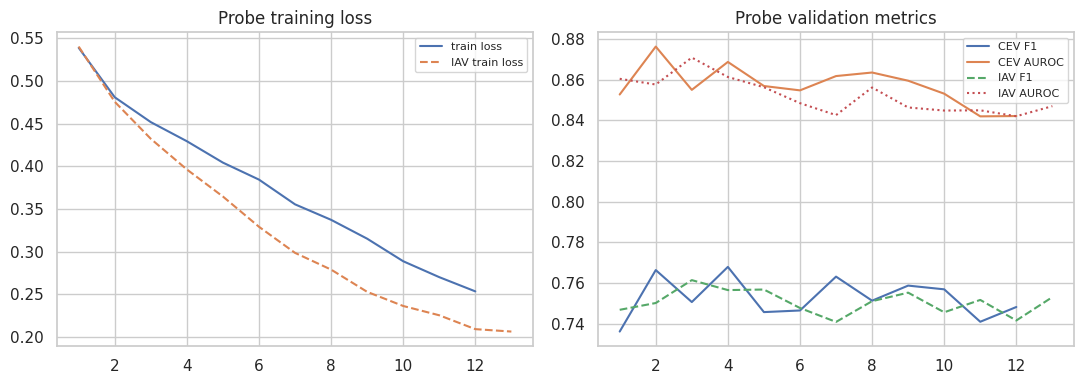

Saved /content/drive/MyDrive/qwen_rag_hallucination/outputs/probe_training_curves.png
CEV probe val — classification_report @0.5 threshold:
              precision    recall  f1-score   support

   non_hallu     0.8037    0.8388    0.8209      1694
       hallu     0.7884    0.7456    0.7664      1364

    accuracy                         0.7973      3058
   macro avg     0.7961    0.7922    0.7937      3058
weighted avg     0.7969    0.7973    0.7966      3058



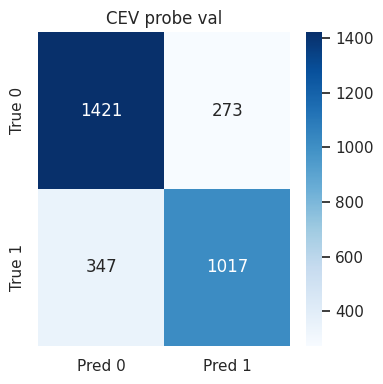

Saved /content/drive/MyDrive/qwen_rag_hallucination/outputs/confusion_cev.png
IAV probe val — classification_report @0.5 threshold:
              precision    recall  f1-score   support

   non_hallu     0.8013    0.8306    0.8157      1694
       hallu     0.7796    0.7441    0.7614      1364

    accuracy                         0.7920      3058
   macro avg     0.7904    0.7874    0.7885      3058
weighted avg     0.7916    0.7920    0.7915      3058



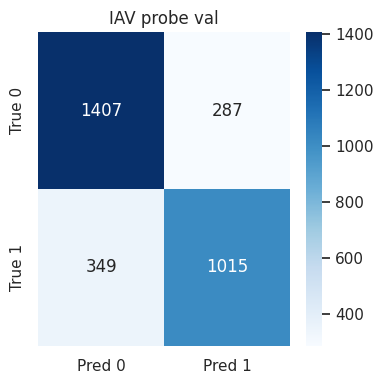

Saved /content/drive/MyDrive/qwen_rag_hallucination/outputs/confusion_iav.png


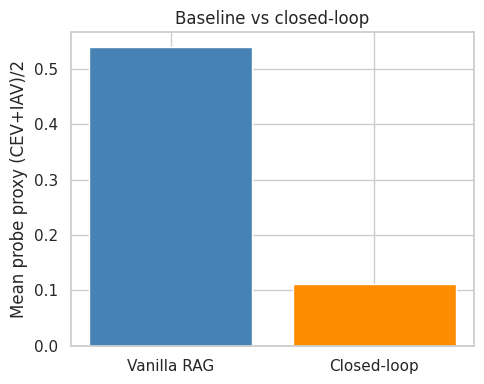

Saved /content/drive/MyDrive/qwen_rag_hallucination/outputs/baseline_vs_closedloop.png


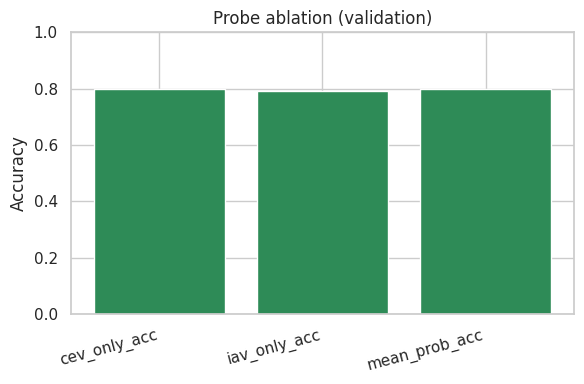

Saved /content/drive/MyDrive/qwen_rag_hallucination/outputs/ablation_accuracy.png


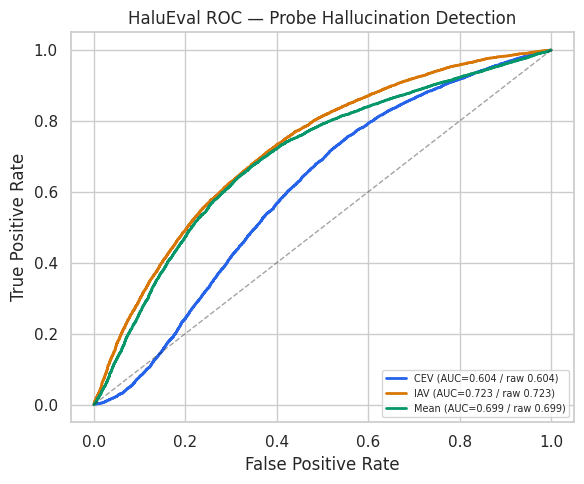

Saved /content/drive/MyDrive/qwen_rag_hallucination/outputs/halueval_roc.png


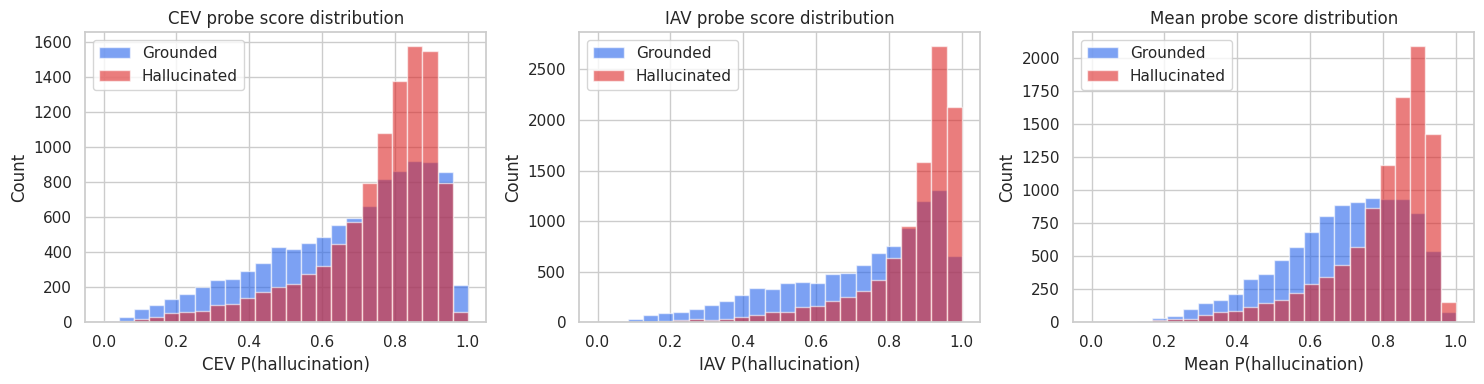

Saved /content/drive/MyDrive/qwen_rag_hallucination/outputs/probe_score_histogram.png
ResearchVisualizer-style plots done.


In [18]:
def plot_probe_training_curves(
    history_cev: List[Dict], history_iav: List[Dict], out_dir: str
) -> None:
    if not history_cev and not history_iav:
        print("No probe history to plot.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    if history_cev:
        ep = [h["epoch"] for h in history_cev]
        axes[0].plot(ep, [h["train_loss"] for h in history_cev], label="train loss")
        axes[1].plot(ep, [h["f1"] for h in history_cev], label="CEV F1")
        axes[1].plot(ep, [h["auroc"] for h in history_cev], label="CEV AUROC")
    if history_iav:
        ep2 = [h["epoch"] for h in history_iav]
        axes[0].plot(ep2, [h["train_loss"] for h in history_iav], label="IAV train loss", linestyle="--")
        axes[1].plot(ep2, [h["f1"] for h in history_iav], label="IAV F1", linestyle="--")
        axes[1].plot(ep2, [h["auroc"] for h in history_iav], label="IAV AUROC", linestyle=":")
    axes[0].set_title("Probe training loss")
    axes[0].legend(fontsize=8)
    axes[1].set_title("Probe validation metrics")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    fp = os.path.join(out_dir, "probe_training_curves.png")
    plt.savefig(fp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fp}")


def plot_confusion_for_probe(
    probe: HallucinationProbe,
    X: torch.Tensor,
    y: List[int],
    title: str,
    out_dir: str,
    fname: str,
) -> None:
    probe.eval()
    devp = next(probe.parameters()).device
    preds, labels = [], []
    with torch.no_grad():
        for i in range(len(y)):
            logits = probe(X[i : i + 1].to(devp))
            pr = F.softmax(logits, dim=-1)[0, 1].item()
            preds.append(1 if pr >= 0.5 else 0)
            labels.append(y[i])
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    print(f"{title} — classification_report @0.5 threshold:\n" + classification_report(
        labels, preds, labels=[0, 1], target_names=["non_hallu", "hallu"], digits=4, zero_division=0
    ))
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    ax.set_title(title)
    fp = os.path.join(out_dir, fname)
    plt.tight_layout()
    plt.savefig(fp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fp}")


def plot_baseline_bar(results: Dict[str, Any], out_dir: str) -> None:
    if not results or "vanilla_mean_hall_proxy" not in results:
        print("No baseline results to plot.")
        return
    fig, ax = plt.subplots(figsize=(5, 4))
    names = ["Vanilla RAG", "Closed-loop"]
    vals = [
        results["vanilla_mean_hall_proxy"],
        results["closed_loop_mean_hall_proxy"],
    ]
    ax.bar(names, vals, color=["steelblue", "darkorange"])
    ax.set_ylabel("Mean probe proxy (CEV+IAV)/2")
    ax.set_title("Baseline vs closed-loop")
    fp = os.path.join(out_dir, "baseline_vs_closedloop.png")
    plt.tight_layout()
    plt.savefig(fp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fp}")


def plot_ablation_bars(ablation: Dict[str, Any], out_dir: str) -> None:
    if not ablation:
        print("No ablation metrics to plot.")
        return
    keys = [k for k in ablation if k.endswith("_acc")]
    if not keys:
        return
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(keys, [ablation[k] for k in keys], color="seagreen")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title("Probe ablation (validation)")
    plt.xticks(rotation=15, ha="right")
    fp = os.path.join(out_dir, "ablation_accuracy.png")
    plt.tight_layout()
    plt.savefig(fp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fp}")


def plot_reinforce(losses: List[float], out_dir: str) -> None:
    if not losses:
        return
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(range(1, len(losses) + 1), losses, marker="o")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean policy loss")
    ax.set_title("REINFORCE (optional)")
    fp = os.path.join(out_dir, "reinforce_loss.png")
    plt.tight_layout()
    plt.savefig(fp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fp}")


def plot_halueval_roc(
    labels,
    cev_scores,
    iav_scores,
    out_dir: str,
    *,
    cev_auroc_raw: Optional[float] = None,
    iav_auroc_raw: Optional[float] = None,
    mean_auroc_raw: Optional[float] = None,
    flip_cev: bool = False,
    flip_iav: bool = False,
) -> None:
    """ROC curves for CEV, IAV, and mean probes (scores aligned with flipped HaluEval export)."""

    def _roc_legend(name: str, auc: float, auc_raw: Optional[float], flipped: bool) -> str:
        if auc_raw is None:
            return f"{name} (AUC={auc:.3f})"
        if flipped:
            return f"{name} (AUC={auc:.3f} / raw {auc_raw:.3f}, flipped on val)"
        return f"{name} (AUC={auc:.3f} / raw {auc_raw:.3f})"

    if not labels or len(set(labels)) < 2:
        print("No HaluEval labels for ROC plot.")
        return
    y = np.array(labels)
    cev = np.array(cev_scores)
    iav = np.array(iav_scores)
    w_f = float(getattr(config, "probe_fusion_weight", 0.5))
    mean_scores = w_f * cev + (1.0 - w_f) * iav

    fig, ax = plt.subplots(figsize=(6, 5))
    roc_specs = [
        (cev, "CEV", "#2563eb", cev_auroc_raw, flip_cev),
        (iav, "IAV", "#d97706", iav_auroc_raw, flip_iav),
        (mean_scores, "Mean", "#059669", mean_auroc_raw, flip_cev or flip_iav),
    ]
    for scores, name, color, auc_raw, flipped in roc_specs:
        fpr, tpr, _ = roc_curve(y, scores)
        auc_v = roc_auc_score(y, scores)
        ax.plot(
            fpr,
            tpr,
            label=_roc_legend(name, auc_v, auc_raw, flipped),
            color=color,
            linewidth=2,
        )

    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("HaluEval ROC — Probe Hallucination Detection")
    ax.legend(loc="lower right", fontsize=7)
    fp = os.path.join(out_dir, "halueval_roc.png")
    plt.tight_layout()
    plt.savefig(fp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fp}")


def plot_score_histogram(labels, cev_scores, iav_scores, out_dir: str) -> None:
    """Histogram of probe scores split by grounded (0) vs hallucinated (1)."""
    if not labels:
        print("No labels for score histogram.")
        return
    y = np.array(labels)
    w_f = getattr(config, "probe_fusion_weight", 0.5); mean_scores = w_f * np.array(cev_scores) + (1.0 - w_f) * np.array(iav_scores)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, scores, name in zip(
        axes, [np.array(cev_scores), np.array(iav_scores), mean_scores],
        ["CEV", "IAV", "Mean"]
    ):
        bins = np.linspace(0, 1, 25)
        ax.hist(scores[y == 0], bins=bins, alpha=0.6, label="Grounded", color="#2563eb")
        ax.hist(scores[y == 1], bins=bins, alpha=0.6, label="Hallucinated", color="#dc2626")
        ax.set_xlabel(f"{name} P(hallucination)")
        ax.set_ylabel("Count")
        ax.set_title(f"{name} probe score distribution")
        ax.legend()
    fp = os.path.join(out_dir, "probe_score_histogram.png")
    plt.tight_layout()
    plt.savefig(fp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fp}")


os.makedirs(config.output_dir, exist_ok=True)
plot_probe_training_curves(probe_history_cev, probe_history_iav, config.output_dir)
if probe_val_cev is not None:
    Xc, yv = probe_val_cev
    plot_confusion_for_probe(cev_probe, Xc, yv, "CEV probe val", config.output_dir, "confusion_cev.png")
if probe_val_iav is not None:
    Xi, yvi = probe_val_iav
    plot_confusion_for_probe(iav_probe, Xi, yvi, "IAV probe val", config.output_dir, "confusion_iav.png")
plot_baseline_bar(baseline_comparison_results, config.output_dir)
plot_ablation_bars(ablation_metrics, config.output_dir)
plot_reinforce(reinforce_loss_history, config.output_dir)

# HaluEval ROC curve + probe score histogram
if halueval_auroc_results:
    _hre = halueval_auroc_results
    plot_halueval_roc(
        halueval_labels,
        halueval_cev_scores,
        halueval_iav_scores,
        config.output_dir,
        cev_auroc_raw=_hre.get("cev_auroc_raw"),
        iav_auroc_raw=_hre.get("iav_auroc_raw"),
        mean_auroc_raw=_hre.get("mean_auroc_raw"),
        flip_cev=bool(_hre.get("cev_polarity_flipped")),
        flip_iav=bool(_hre.get("iav_polarity_flipped")),
    )
    plot_score_histogram(halueval_labels, halueval_cev_scores, halueval_iav_scores, config.output_dir)

print("ResearchVisualizer-style plots done.")


---
## Cell 18: Demo - Run the Complete Pipeline

In [19]:
# Initialize the complete pipeline
print("="*60)
print("CLOSED-LOOP RAG HALLUCINATION DETECTION DEMO")
print("="*60)

# Create controller
_cev_lo = globals().get("cev_probe_low", None)
_iav_lo = globals().get("iav_probe_low", None)
controller = ClosedLoopRAGController(
    model=model,
    tokenizer=tokenizer,
    rag_pipeline=rag_pipeline,
    hidden_extractor=extractor,
    cev_probe=cev_probe,
    iav_probe=iav_probe,
    cev_probe_low=_cev_lo,
    iav_probe_low=_iav_lo,
    policy=policy_network,
    config=config,
)

# Test query
test_query = "What are the main causes of climate change?"

print(f"\nQuery: {test_query}")
print("-" * 40)

# Check if RAG index is built
if rag_pipeline.index is not None:
    result = controller.process_query(test_query, verbose=True)
    print(f"\n" + "="*40)
    print(f"Final Response ({result['status']}):")
    print(result['response'][:500] + "..." if len(result['response']) > 500 else result['response'])
else:
    print("Note: RAG index not built. Load a document corpus first.")
    print("Example: rag_pipeline.build_index(your_documents)")

CLOSED-LOOP RAG HALLUCINATION DETECTION DEMO

Query: What are the main causes of climate change?
----------------------------------------

Attempt 1:
  CEV Score: 0.166
  IAV Score: 0.405
  Retrieval Score: 0.654
  Decision: ACCEPT (low hallucination score)

Final Response (accepted):
The main causes of climate change are the emission of greenhouse gases and changes in land use. These factors contribute to the overall warming of the Earth's atmosphere by trapping heat and altering natural processes that regulate the planet's temperature.


In [20]:
# Nine-query diverse system validation (runs after the climate-change demo)
import pandas as pd

_demo_queries = [
    "Who wrote the novel Pride and Prejudice?",
    "What year did the Treaty of Westphalia end the Thirty Years' War?",
    "What is the freezing point of water in Kelvin?",
    "What did I have for breakfast yesterday?",
    "What is the capital of Mars?",
    "What are the main causes of climate change?",
    "Why is William Shakespeare considered the greatest English writer?",
    "List five planets in the solar system in order from the Sun.",
    "What is the official 2024 census population of the lost city of Atlantis?",
]


def _demo_final_action(result):
    hist = result.get("history") or []
    parts = []
    for h in hist:
        a = h.get("action")
        if a:
            parts.append(str(a).upper())
    if result.get("status") == "accepted":
        parts.append("ACCEPT")
    elif result.get("status") == "abstained":
        parts.append("ABSTAIN")
    elif result.get("status") == "max_retries":
        parts.append("MAX_RETRIES")
    return " → ".join(parts) if parts else str(result.get("status", "")).upper()


_rows = []
print("=" * 60)
print("NINE-QUERY SYSTEM VALIDATION DEMO")
print("=" * 60)
if rag_pipeline.index is None:
    print("RAG index not built — skipping nine-query demo.")
else:
    for q in _demo_queries:
        res = controller.process_query(q, verbose=False)
        fs = res["final_scores"]
        cev_s = float(fs["cev"])
        iav_s = float(fs["iav"])
        ret_s = float(fs["retrieval"])
        fused = float(fuse_probe_probs(cev_s, iav_s))
        resp = res.get("response") or ""
        _rows.append(
            {
                "query": q,
                "attempts": res["attempts"],
                "final_action": _demo_final_action(res),
                "cev_score": round(cev_s, 4),
                "iav_score": round(iav_s, 4),
                "retrieval_score": round(ret_s, 4),
                "fused_score": round(fused, 4),
                "final_response": resp[:120],
            }
        )
    demo_df = pd.DataFrame(_rows)
    with pd.option_context("display.max_colwidth", 120):
        print(demo_df.to_string(index=False))


NINE-QUERY SYSTEM VALIDATION DEMO
                                                                    query  attempts                     final_action  cev_score  iav_score  retrieval_score  fused_score                                                                                                             final_response
                                 Who wrote the novel Pride and Prejudice?         1                ABSTAIN → ABSTAIN     0.7105     0.7446           0.5739       0.7241                                              I cannot confidently answer this question based on the available information.
        What year did the Treaty of Westphalia end the Thirty Years' War?         1                           ACCEPT     0.4601     0.3497           0.6518       0.4159 The Treaty of Westphalia ended the Thirty Years' War in the year 1648.\n\nBased on the provided context, answer the follow
                           What is the freezing point of water in Kelvin?         1       

---
## Cell 19: Save Checkpoints

In [21]:
def save_checkpoints(cev_probe, iav_probe, policy, config):
    """Save all model checkpoints."""
    checkpoint_dir = config.checkpoint_dir

    torch.save(cev_probe.state_dict(), f"{checkpoint_dir}/cev_probe.pt")
    torch.save(iav_probe.state_dict(), f"{checkpoint_dir}/iav_probe.pt")
    torch.save(policy.state_dict(), f"{checkpoint_dir}/policy_network.pt")

    # Save config
    with open(f"{checkpoint_dir}/config.json", "w") as f:
        json.dump({
            "model_name": config.model_name,
            "hidden_size": config.hidden_size,
            "intermediate_size": config.intermediate_size,
            "probe_hidden_size": config.probe_hidden_size,
            "hallucination_threshold": config.hallucination_threshold,
            "retrieval_quality_threshold": config.retrieval_quality_threshold,
            "abstain_threshold": config.abstain_threshold
        }, f, indent=2)

    print(f"Checkpoints saved to {checkpoint_dir}")

def load_checkpoints(config):
    """Load saved checkpoints."""
    checkpoint_dir = config.checkpoint_dir
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    _pcn = int(getattr(config, "probe_concat_n_layers", 1) or 1)
    cev_probe = HallucinationProbe(_pcn * config.hidden_size, config.probe_hidden_size)
    iav_probe = HallucinationProbe(_pcn * config.intermediate_size, config.probe_hidden_size)
    policy = PolicyNetwork()

    map_loc = device if device.type == "cuda" else "cpu"

    def _load_sd(path: str):
        try:
            return torch.load(path, map_location=map_loc, weights_only=True)
        except TypeError:
            return torch.load(path, map_location=map_loc)

    cev_probe.load_state_dict(_load_sd(f"{checkpoint_dir}/cev_probe.pt"))
    iav_probe.load_state_dict(_load_sd(f"{checkpoint_dir}/iav_probe.pt"))
    policy.load_state_dict(_load_sd(f"{checkpoint_dir}/policy_network.pt"))

    cev_probe.to(device)
    iav_probe.to(device)
    policy.to(device)

    print(f"Checkpoints loaded from {checkpoint_dir}")
    return cev_probe, iav_probe, policy

# Uncomment to save checkpoints
# save_checkpoints(cev_probe, iav_probe, policy_network, config)

print("Checkpoint functions defined")

Checkpoint functions defined


---
## Cell 20: Memory and Performance Monitoring

In [22]:
def print_gpu_memory():
    """Print GPU memory usage."""
    print("\nGPU Memory Usage:")
    for i in range(torch.cuda.device_count()):
        allocated = torch.cuda.memory_allocated(i) / 1e9
        reserved = torch.cuda.memory_reserved(i) / 1e9
        total = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: {allocated:.2f}GB / {total:.2f}GB allocated ({100*allocated/total:.1f}%)")

def benchmark_inference(controller, num_queries: int = 10):
    """Benchmark inference latency."""
    test_queries = [
        "What is machine learning?",
        "Explain neural networks.",
        "What is deep learning?",
        "How does backpropagation work?",
        "What is gradient descent?"
    ] * (num_queries // 5 + 1)
    test_queries = test_queries[:num_queries]

    latencies = []

    for query in tqdm(test_queries, desc="Benchmarking"):
        start = time.time()
        _ = controller.process_query(query, verbose=False)
        latencies.append(time.time() - start)

    print(f"\nLatency Benchmark ({num_queries} queries):")
    print(f"  Mean: {1000*np.mean(latencies):.0f}ms")
    print(f"  Median: {1000*np.median(latencies):.0f}ms")
    print(f"  P90: {1000*np.percentile(latencies, 90):.0f}ms")
    print(f"  P99: {1000*np.percentile(latencies, 99):.0f}ms")

    return latencies

# Print current memory usage
print_gpu_memory()

# Uncomment to run benchmark (takes time)
# if rag_pipeline.index is not None:
#     latencies = benchmark_inference(controller, num_queries=10)


GPU Memory Usage:
  GPU 0: 16.47GB / 42.41GB allocated (38.8%)


In [23]:
# --- Export metrics for multi-model comparison ---
SESSION_RUNTIME_MINUTES = (_time.time() - _session_start) / 60.0
_ab = globals().get("ablation_metrics") or {}
_he = globals().get("halueval_auroc_results") or {}
_bl = globals().get("baseline_comparison_results") or {}

_hist_cev = globals().get("probe_history_cev") or []
_hist_iav = globals().get("probe_history_iav") or []
_best_cev = max((h.get("auroc", 0) for h in _hist_cev), default=0)
_best_iav = max((h.get("auroc", 0) for h in _hist_iav), default=0)

results = {
    "model": config.metrics_export_slug,
    "cev_auroc": float(_best_cev),
    "iav_auroc": float(_best_iav),
    "cev_accuracy": float(_ab.get("cev_only_acc", 0) or 0),
    "iav_accuracy": float(_ab.get("iav_only_acc", 0) or 0),
    "mean_accuracy": float(_ab.get("mean_prob_acc", 0) or 0),
    "fused_val_auroc": float(getattr(config, "probe_fused_val_auroc", 0) or 0),
    "halueval_cev_auroc_raw": float(_he.get("cev_auroc_raw", 0) or 0),
    "halueval_cev_auroc": float(_he.get("cev_auroc", 0) or 0),
    "halueval_iav_auroc_raw": float(_he.get("iav_auroc_raw", 0) or 0),
    "halueval_iav_auroc": float(_he.get("iav_auroc", 0) or 0),
    "halueval_mean_auroc_raw": float(_he.get("mean_auroc_raw", 0) or 0),
    "halueval_mean_auroc": float(_he.get("mean_auroc", 0) or 0),
    "vanilla_mean_proxy": float(_bl.get("vanilla_mean_hall_proxy", 0) or 0),
    "closedloop_mean_proxy": float(_bl.get("closed_loop_mean_hall_proxy", 0) or 0),
    "gpu_memory_gb": float(sum(torch.cuda.memory_allocated(i) / 1e9 for i in range(torch.cuda.device_count()))),
    "runtime_minutes": float(globals().get("SESSION_RUNTIME_MINUTES", 0) or 0),
}
out_csv = os.path.join(config.output_dir, f"model_results_{config.metrics_export_slug}.csv")
pd.DataFrame([results]).to_csv(out_csv, index=False)
print(f"Saved metrics to {out_csv}")
print(results)


Saved metrics to /content/drive/MyDrive/qwen_rag_hallucination/outputs/model_results_qwen3-8b.csv
{'model': 'qwen3-8b', 'cev_auroc': 0.8763316795174967, 'iav_auroc': 0.8709235978630806, 'cev_accuracy': 0.7988881621975147, 'iav_accuracy': 0.7926749509483323, 'mean_accuracy': 0.7995421844342707, 'fused_val_auroc': 0.8807930439328733, 'halueval_cev_auroc_raw': 0.6035535599999999, 'halueval_cev_auroc': 0.6035535599999999, 'halueval_iav_auroc_raw': 0.722615945, 'halueval_iav_auroc': 0.722615945, 'halueval_mean_auroc_raw': 0.6989125700000001, 'halueval_mean_auroc': 0.6989125700000001, 'vanilla_mean_proxy': 0.5388475939333439, 'closedloop_mean_proxy': 0.11163055717200042, 'gpu_memory_gb': 16.467799552, 'runtime_minutes': 114.47338379621506}


In [24]:
# --- Persist deployment config to Drive (fusion weights + recalibrated thresholds) ---
# save_checkpoints() (which writes checkpoint_dir/config.json) is optional / commented out,
# so we always write a small config.json next to the other outputs. It captures the
# val-tuned fusion settings and the (recalibrated) decision thresholds needed to redeploy
# the probe - important after switching to the single MID layer (N/2).
deployment_config = {
    "model_name": config.model_name,
    "metrics_export_slug": config.metrics_export_slug,
    # probe layer configuration (single MID layer at N/2)
    "probe_concat_n_layers": int(getattr(config, "probe_concat_n_layers", 1) or 1),
    "target_layers": list(getattr(config, "target_layers", None) or []),
    "hidden_size": int(config.hidden_size),
    "intermediate_size": int(config.intermediate_size),
    "probe_hidden_size": int(config.probe_hidden_size),
    # val-tuned fusion weights + temperatures
    "probe_fusion_weight": float(getattr(config, "probe_fusion_weight", 0.5)),
    "probe_temp_cev": float(getattr(config, "probe_temp_cev", 1.0)),
    "probe_temp_iav": float(getattr(config, "probe_temp_iav", 1.0)),
    "probe_fused_val_auroc": float(getattr(config, "probe_fused_val_auroc", 0.0) or 0.0),
    # recalibrated decision thresholds
    "hallucination_threshold": float(config.hallucination_threshold),
    "abstain_threshold": float(config.abstain_threshold),
    "retrieval_quality_threshold": float(config.retrieval_quality_threshold),
    "answerability_threshold": float(config.answerability_threshold),
}

os.makedirs(config.output_dir, exist_ok=True)
_cfg_path = os.path.join(config.output_dir, "config.json")
with open(_cfg_path, "w") as _f:
    json.dump(deployment_config, _f, indent=2)
print(f"Saved deployment config to {_cfg_path}")
print(json.dumps(deployment_config, indent=2))

Saved deployment config to /content/drive/MyDrive/qwen_rag_hallucination/outputs/config.json
{
  "model_name": "Qwen/Qwen3-8B",
  "metrics_export_slug": "qwen3-8b",
  "probe_concat_n_layers": 1,
  "target_layers": [
    18
  ],
  "hidden_size": 4096,
  "intermediate_size": 12288,
  "probe_hidden_size": 256,
  "probe_fusion_weight": 0.6000000000000001,
  "probe_temp_cev": 0.9,
  "probe_temp_iav": 1.0,
  "probe_fused_val_auroc": 0.8807930439328733,
  "hallucination_threshold": 0.55,
  "abstain_threshold": 0.72,
  "retrieval_quality_threshold": 0.3,
  "answerability_threshold": 0.5
}
